# Caso de Estudio 2 — Sistema de Recompensas de McDonald's

## Prueba de concepto de la arquitectura de datos

Este notebook implementa una réplica en miniatura de la arquitectura de datos propuesta para el sistema de recompensas de McDonald's.

La POC simula el recorrido de los datos desde los diferentes canales de compra (App móvil, POS/Caja, Kiosco, AutoMac y McDelivery), pasando por los sistemas operacionales y el sistema de puntos, hasta llegar al pipeline de datos, Data Warehouse y capa de analítica y Machine Learning.


### Arquitectura simulada



**1. Canales y fuentes**
- App móvil
- POS / Caja
- Kiosco
- AutoMac
- McDelivery

**2. Servicios y datos operacionales**
- Clientes
- Órdenes
- Reglas del programa
- Catálogo de recompensas
- Ledger de puntos

**3. Eventos transaccionales**
- ORDER_PAID
- POINTS_EARNED
- REDEEMED
- EXPIRED

**4. Pipeline de datos**
- Raw Data Lake
- ETL
- Data Quality
- Data Warehouse

**5. Analítica y Machine Learning**
- KPIs del programa de recompensas
- Feature Engineering
- Modelo de abandono
- Identificación de clientes para campañas personalizadas

El objetivo es demostrar de forma funcional cómo los datos generados por el sistema de recompensas pueden ser procesados, validados y utilizados posteriormente para análisis y modelos predictivos.

## 2. Simulación de datos operacionales



La arquitectura propuesta cuenta con diferentes bases de datos operacionales que almacenan la información necesaria para el funcionamiento del sistema de recompensas. En esta sección se simulan estas fuentes de datos mediante DataFrames de Pandas. Estos datos representan una versión simplificada de los sistemas transaccionales reales.

In [1]:
# ============================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import random

# Configuración para visualizar mejor los DataFrames
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Semillas para garantizar reproducibilidad
np.random.seed(42)
random.seed(42)

print("Librerías cargadas correctamente.")
print("Fecha de ejecución:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

Librerías cargadas correctamente.
Fecha de ejecución: 2026-09-22 18:03:47


### 2.1 Customer DB


Customer DB almacena la información de los clientes registrados en el programa de recompensas. Cada cliente posee un identificador único que permite relacionar sus compras, puntos y canjes a través de los diferentes canales.

In [2]:
# ============================================
# 2.1 CUSTOMER DB
# ============================================

n_customers = 200

# Fecha de referencia de la simulación
fecha_referencia = pd.Timestamp("2026-09-22")

# Generamos identificadores únicos
customer_ids = [f"CUST_{i:04d}" for i in range(1, n_customers + 1)]

# Simulación de clientes
df_customers = pd.DataFrame({
    "customer_id": customer_ids,

    "fecha_registro": [
        fecha_referencia - pd.Timedelta(days=random.randint(30, 1000))
        for _ in range(n_customers)
    ],

    "ciudad": np.random.choice(
        ["Ciudad de Guatemala", "Mixco", "Villa Nueva",
         "Antigua Guatemala", "Quetzaltenango"],
        size=n_customers,
        p=[0.45, 0.20, 0.15, 0.10, 0.10]
    ),

    "estado_cuenta": np.random.choice(
        ["activa", "inactiva"],
        size=n_customers,
        p=[0.92, 0.08]
    ),

    "acepta_promociones": np.random.choice(
        [True, False],
        size=n_customers,
        p=[0.75, 0.25]
    )
})

# Ordenamos por identificador
df_customers = df_customers.sort_values("customer_id").reset_index(drop=True)

print("CUSTOMER DB")
print("-" * 50)
print(f"Total de clientes: {len(df_customers)}")

display(df_customers.head(10))

CUSTOMER DB
--------------------------------------------------
Total de clientes: 200


,customer_id,fecha_registro,ciudad,estado_cuenta,acepta_promociones
0,CUST_0001,2024-11-07,Ciudad de Guatemala,activa,True
1,CUST_0002,2026-05-01,Quetzaltenango,activa,False
2,CUST_0003,2026-07-29,Villa Nueva,activa,True
3,CUST_0004,2024-07-25,Mixco,activa,False
4,CUST_0005,2025-11-15,Ciudad de Guatemala,activa,True
5,CUST_0006,2025-12-16,Ciudad de Guatemala,activa,False
6,CUST_0007,2026-01-07,Ciudad de Guatemala,activa,True
7,CUST_0008,2026-04-03,Antigua Guatemala,activa,True
8,CUST_0009,2024-07-30,Mixco,activa,False
9,CUST_0010,2026-05-11,Villa Nueva,activa,True


### 2.2 Rules DB


Rules DB representa el repositorio de reglas utilizadas por el programa de recompensas. Estas reglas son consultadas por el Rules Engine para determinar cómo se asignan los puntos a cada transacción.

Para esta prueba de concepto se utiliza una regla simplificada de acumulación de puntos. Las reglas definidas en esta sección son simuladas con fines académicos y permiten demostrar el funcionamiento del pipeline de datos.

In [3]:
# ============================================
# 2.2 RULES DB
# ============================================

df_rules = pd.DataFrame([
    {
        "rule_id": "RULE_001",
        "nombre_regla": "Acumulación estándar",
        "tipo_regla": "earn",
        "puntos_por_quetzal": 10,
        "monto_minimo": 1.00,
        "fecha_inicio": pd.Timestamp("2026-01-01"),
        "fecha_fin": pd.NaT,
        "activa": True
    },
    {
        "rule_id": "RULE_002",
        "nombre_regla": "Bono App móvil",
        "tipo_regla": "bonus",
        "puntos_por_quetzal": 2,
        "monto_minimo": 20.00,
        "fecha_inicio": pd.Timestamp("2026-01-01"),
        "fecha_fin": pd.NaT,
        "activa": True
    }
])

print("RULES DB")
print("-" * 50)
print(f"Total de reglas configuradas: {len(df_rules)}")

display(df_rules)

RULES DB
--------------------------------------------------
Total de reglas configuradas: 2


,rule_id,nombre_regla,tipo_regla,puntos_por_quetzal,monto_minimo,fecha_inicio,fecha_fin,activa
0,RULE_001,Acumulación estándar,earn,10,1.0,2026-01-01,NaT,True
1,RULE_002,Bono App móvil,bonus,2,20.0,2026-01-01,NaT,True


### 2.3 Rewards DB


Rewards DB almacena el catálogo de recompensas disponibles para los clientes del programa de lealtad.

Cada recompensa posee un identificador, una categoría, un costo en puntos y un estado de disponibilidad. El Reward Service consulta esta información para determinar qué productos pueden ser canjeados por un cliente según su saldo de puntos.

Para esta prueba de concepto se utiliza un catálogo simplificado de recompensas con valores simulados con fines académicos.

In [4]:
# ============================================
# 2.3 REWARDS DB
# ============================================

df_rewards = pd.DataFrame([
    {
        "reward_id": "REW_001",
        "nombre_recompensa": "Papas pequeñas",
        "categoria": "Acompañamiento",
        "costo_puntos": 1500,
        "disponible": True
    },
    {
        "reward_id": "REW_002",
        "nombre_recompensa": "Bebida mediana",
        "categoria": "Bebida",
        "costo_puntos": 2000,
        "disponible": True
    },
    {
        "reward_id": "REW_003",
        "nombre_recompensa": "Sundae",
        "categoria": "Postre",
        "costo_puntos": 2500,
        "disponible": True
    },
    {
        "reward_id": "REW_004",
        "nombre_recompensa": "Hamburguesa",
        "categoria": "Producto principal",
        "costo_puntos": 4000,
        "disponible": True
    },
    {
        "reward_id": "REW_005",
        "nombre_recompensa": "McNuggets 6 piezas",
        "categoria": "Producto principal",
        "costo_puntos": 5000,
        "disponible": True
    },
    {
        "reward_id": "REW_006",
        "nombre_recompensa": "McCombo",
        "categoria": "Combo",
        "costo_puntos": 7500,
        "disponible": True
    }
])

print("REWARDS DB")
print("-" * 50)
print(f"Total de recompensas: {len(df_rewards)}")
print(f"Recompensas disponibles: {df_rewards['disponible'].sum()}")

display(df_rewards)


REWARDS DB
--------------------------------------------------
Total de recompensas: 6
Recompensas disponibles: 6


,reward_id,nombre_recompensa,categoria,costo_puntos,disponible
0,REW_001,Papas pequeñas,Acompañamiento,1500,True
1,REW_002,Bebida mediana,Bebida,2000,True
2,REW_003,Sundae,Postre,2500,True
3,REW_004,Hamburguesa,Producto principal,4000,True
4,REW_005,McNuggets 6 piezas,Producto principal,5000,True
5,REW_006,McCombo,Combo,7500,True


### 2.4 Orders DB

Orders DB representa la base de datos transaccional donde se almacenan las órdenes realizadas por los clientes.

Las transacciones pueden originarse desde los distintos canales definidos en la arquitectura: App móvil, POS/Caja, Kiosco, AutoMac y McDelivery. Cada orden se relaciona con un cliente mediante `customer_id` e incluye información como fecha, canal, monto y estado del pago.

Para esta prueba de concepto se generan transacciones sintéticas que posteriormente serán procesadas por el sistema de lealtad y el pipeline de datos.

In [5]:
# ============================================
# 2.4 ORDERS DB
# ============================================

n_orders = 1500

canales = [
    "App móvil",
    "POS / Caja",
    "Kiosco",
    "AutoMac",
    "McDelivery"
]

# Generamos fechas de compra durante los últimos 365 días
fechas_ordenes = [
    fecha_referencia - pd.Timedelta(
        days=random.randint(0, 364),
        hours=random.randint(0, 23),
        minutes=random.randint(0, 59)
    )
    for _ in range(n_orders)
]

# Generamos montos de compra con una distribución realista
# y limitamos los valores extremos.
montos = np.round(
    np.clip(
        np.random.gamma(shape=2.5, scale=22, size=n_orders),
        10,
        250
    ),
    2
)

df_orders = pd.DataFrame({
    "order_id": [
        f"ORD_{i:06d}"
        for i in range(1, n_orders + 1)
    ],

    "customer_id": np.random.choice(
        df_customers["customer_id"],
        size=n_orders,
        replace=True
    ),

    "fecha_orden": fechas_ordenes,

    "canal": np.random.choice(
        canales,
        size=n_orders,
        p=[0.30, 0.25, 0.20, 0.15, 0.10]
    ),

    "monto_total": montos,

    "estado_orden": np.random.choice(
        ["PAGADA", "CANCELADA"],
        size=n_orders,
        p=[0.95, 0.05]
    )
})

# Ordenamos cronológicamente
df_orders = (
    df_orders
    .sort_values("fecha_orden")
    .reset_index(drop=True)
)

print("ORDERS DB")
print("-" * 50)

print(f"Total de órdenes: {len(df_orders):,}")
print(f"Órdenes pagadas: {(df_orders['estado_orden'] == 'PAGADA').sum():,}")
print(f"Órdenes canceladas: {(df_orders['estado_orden'] == 'CANCELADA').sum():,}")

print("\nÓrdenes por canal:")
print(df_orders["canal"].value_counts())

display(df_orders.head(10))

ORDERS DB
--------------------------------------------------
Total de órdenes: 1,500
Órdenes pagadas: 1,430
Órdenes canceladas: 70

Órdenes por canal:
canal
App móvil     484
POS / Caja    374
Kiosco        294
AutoMac       208
McDelivery    140
Name: count, dtype: int64


,order_id,customer_id,fecha_orden,canal,monto_total,estado_orden
0,ORD_001095,CUST_0122,2025-09-22 11:01:00,Kiosco,42.24,PAGADA
1,ORD_001268,CUST_0074,2025-09-22 13:07:00,AutoMac,130.11,PAGADA
2,ORD_001407,CUST_0120,2025-09-22 15:55:00,POS / Caja,35.49,PAGADA
3,ORD_001432,CUST_0109,2025-09-22 16:38:00,AutoMac,15.62,PAGADA
4,ORD_000762,CUST_0045,2025-09-23 01:20:00,App móvil,50.20,PAGADA
5,ORD_000573,CUST_0008,2025-09-23 03:34:00,App móvil,71.89,PAGADA
6,ORD_001255,CUST_0179,2025-09-23 04:20:00,POS / Caja,47.79,PAGADA
7,ORD_001237,CUST_0110,2025-09-23 09:29:00,App móvil,59.32,PAGADA
8,ORD_000782,CUST_0075,2025-09-23 16:38:00,App móvil,79.04,PAGADA
9,ORD_001194,CUST_0009,2025-09-23 20:59:00,App móvil,19.50,PAGADA


## 3. Procesamiento del sistema de lealtad

### 3.1 Loyalty Service y Rules Engine


Una vez registrada una orden, el sistema de lealtad procesa únicamente aquellas transacciones cuyo pago fue completado exitosamente.

El Loyalty Service consulta las reglas activas almacenadas en Rules DB para calcular los puntos correspondientes a cada compra. En esta prueba de concepto se aplica una regla estándar de acumulación y un bono adicional para las compras realizadas desde la App móvil que cumplen con el monto mínimo definido.

Las órdenes canceladas no generan puntos.

El resultado de este proceso se registra posteriormente en el Points Ledger, manteniendo un historial de los movimientos de puntos asociados a cada cliente.

In [6]:
# ============================================
# 3.1 LOYALTY SERVICE + RULES ENGINE
# ============================================

# 1. El Loyalty Service procesa únicamente órdenes pagadas
df_paid_orders = df_orders[
    df_orders["estado_orden"] == "PAGADA"
].copy()

# 2. Consultamos las reglas activas
regla_estandar = df_rules[
    (df_rules["rule_id"] == "RULE_001") &
    (df_rules["activa"] == True)
].iloc[0]

regla_app = df_rules[
    (df_rules["rule_id"] == "RULE_002") &
    (df_rules["activa"] == True)
].iloc[0]

# 3. Calculamos puntos estándar
df_paid_orders["puntos_base"] = np.floor(
    df_paid_orders["monto_total"] *
    regla_estandar["puntos_por_quetzal"]
).astype(int)

# 4. Identificamos órdenes elegibles para el bono de App
condicion_bono_app = (
    (df_paid_orders["canal"] == "App móvil") &
    (df_paid_orders["monto_total"] >= regla_app["monto_minimo"])
)

# 5. Calculamos puntos adicionales
df_paid_orders["puntos_bono"] = np.where(
    condicion_bono_app,
    np.floor(
        df_paid_orders["monto_total"] *
        regla_app["puntos_por_quetzal"]
    ),
    0
).astype(int)

# 6. Puntos totales obtenidos por cada orden
df_paid_orders["puntos_ganados"] = (
    df_paid_orders["puntos_base"] +
    df_paid_orders["puntos_bono"]
)

print("LOYALTY SERVICE + RULES ENGINE")
print("-" * 55)

print(f"Órdenes procesadas: {len(df_paid_orders):,}")
print(f"Puntos base generados: {df_paid_orders['puntos_base'].sum():,}")
print(f"Puntos de bono generados: {df_paid_orders['puntos_bono'].sum():,}")
print(f"Puntos totales generados: {df_paid_orders['puntos_ganados'].sum():,}")

print(
    f"Órdenes con bono App: "
    f"{condicion_bono_app.sum():,}"
)

display(
    df_paid_orders[
        [
            "order_id",
            "customer_id",
            "fecha_orden",
            "canal",
            "monto_total",
            "puntos_base",
            "puntos_bono",
            "puntos_ganados"
        ]
    ].head(10)
)


LOYALTY SERVICE + RULES ENGINE
-------------------------------------------------------
Órdenes procesadas: 1,430
Puntos base generados: 794,184
Puntos de bono generados: 51,680
Puntos totales generados: 845,864
Órdenes con bono App: 418


,order_id,customer_id,fecha_orden,canal,monto_total,puntos_base,puntos_bono,puntos_ganados
0,ORD_001095,CUST_0122,2025-09-22 11:01:00,Kiosco,42.24,422,0,422
1,ORD_001268,CUST_0074,2025-09-22 13:07:00,AutoMac,130.11,1301,0,1301
2,ORD_001407,CUST_0120,2025-09-22 15:55:00,POS / Caja,35.49,354,0,354
3,ORD_001432,CUST_0109,2025-09-22 16:38:00,AutoMac,15.62,156,0,156
4,ORD_000762,CUST_0045,2025-09-23 01:20:00,App móvil,50.20,502,100,602
5,ORD_000573,CUST_0008,2025-09-23 03:34:00,App móvil,71.89,718,143,861
6,ORD_001255,CUST_0179,2025-09-23 04:20:00,POS / Caja,47.79,477,0,477
7,ORD_001237,CUST_0110,2025-09-23 09:29:00,App móvil,59.32,593,118,711
8,ORD_000782,CUST_0075,2025-09-23 16:38:00,App móvil,79.04,790,158,948
9,ORD_001194,CUST_0009,2025-09-23 20:59:00,App móvil,19.50,195,0,195


In [7]:
# ============================================
# VALIDACIÓN DEL RULES ENGINE
# ============================================

ejemplos_bono = df_paid_orders[
    df_paid_orders["puntos_bono"] > 0
][
    [
        "order_id",
        "canal",
        "monto_total",
        "puntos_base",
        "puntos_bono",
        "puntos_ganados"
    ]
].head(5)

print("Ejemplos de órdenes que recibieron bono por App:")
display(ejemplos_bono)

# Validaciones automáticas
assert (df_paid_orders["puntos_ganados"] >= 0).all()
assert (df_paid_orders["estado_orden"] == "PAGADA").all()

print("✓ Validación completada correctamente.")

Ejemplos de órdenes que recibieron bono por App:


,order_id,canal,monto_total,puntos_base,puntos_bono,puntos_ganados
4,ORD_000762,App móvil,50.20,502,100,602
5,ORD_000573,App móvil,71.89,718,143,861
7,ORD_001237,App móvil,59.32,593,118,711
8,ORD_000782,App móvil,79.04,790,158,948
12,ORD_001058,App móvil,30.06,300,60,360


✓ Validación completada correctamente.


### 3.2 Points Ledger — Registro de créditos


El Points Ledger funciona como el historial transaccional del programa de recompensas. En lugar de almacenar únicamente el saldo actual de cada cliente, registra cada movimiento individual de puntos.

En esta primera etapa se generan los movimientos de crédito asociados a las órdenes pagadas. Cada movimiento mantiene trazabilidad hacia la orden que originó los puntos.

Posteriormente, el mismo ledger incorporará movimientos de débito relacionados con canjes y expiraciones. El saldo de un cliente podrá calcularse como la suma de todos sus movimientos.

In [8]:
# ============================================
# 3.2 POINTS LEDGER - CRÉDITOS
# ============================================

# Creamos un movimiento de crédito por cada orden pagada
df_points_ledger = df_paid_orders[
    [
        "order_id",
        "customer_id",
        "fecha_orden",
        "puntos_ganados"
    ]
].copy()

# Identificador único para cada movimiento
df_points_ledger.insert(
    0,
    "ledger_id",
    [f"LED_{i:06d}" for i in range(1, len(df_points_ledger) + 1)]
)

# Información del movimiento
df_points_ledger["tipo_movimiento"] = "CREDITO"
df_points_ledger["motivo"] = "COMPRA"
df_points_ledger["puntos"] = df_points_ledger["puntos_ganados"]
df_points_ledger["reward_id"] = None

# Renombramos la fecha para representar la fecha del movimiento
df_points_ledger = df_points_ledger.rename(
    columns={"fecha_orden": "fecha_movimiento"}
)

# Eliminamos la columna auxiliar
df_points_ledger = df_points_ledger.drop(
    columns=["puntos_ganados"]
)

# Orden final de columnas
df_points_ledger = df_points_ledger[
    [
        "ledger_id",
        "customer_id",
        "fecha_movimiento",
        "tipo_movimiento",
        "motivo",
        "puntos",
        "order_id",
        "reward_id"
    ]
]

print("POINTS LEDGER")
print("-" * 55)

print(f"Movimientos registrados: {len(df_points_ledger):,}")
print(f"Créditos registrados: {(df_points_ledger['tipo_movimiento'] == 'CREDITO').sum():,}")
print(f"Puntos acreditados: {df_points_ledger['puntos'].sum():,}")

display(df_points_ledger.head(10))

POINTS LEDGER
-------------------------------------------------------
Movimientos registrados: 1,430
Créditos registrados: 1,430
Puntos acreditados: 845,864


,ledger_id,customer_id,fecha_movimiento,tipo_movimiento,motivo,puntos,order_id,reward_id
0,LED_000001,CUST_0122,2025-09-22 11:01:00,CREDITO,COMPRA,422,ORD_001095,None
1,LED_000002,CUST_0074,2025-09-22 13:07:00,CREDITO,COMPRA,1301,ORD_001268,None
2,LED_000003,CUST_0120,2025-09-22 15:55:00,CREDITO,COMPRA,354,ORD_001407,None
3,LED_000004,CUST_0109,2025-09-22 16:38:00,CREDITO,COMPRA,156,ORD_001432,None
4,LED_000005,CUST_0045,2025-09-23 01:20:00,CREDITO,COMPRA,602,ORD_000762,None
5,LED_000006,CUST_0008,2025-09-23 03:34:00,CREDITO,COMPRA,861,ORD_000573,None
6,LED_000007,CUST_0179,2025-09-23 04:20:00,CREDITO,COMPRA,477,ORD_001255,None
7,LED_000008,CUST_0110,2025-09-23 09:29:00,CREDITO,COMPRA,711,ORD_001237,None
8,LED_000009,CUST_0075,2025-09-23 16:38:00,CREDITO,COMPRA,948,ORD_000782,None
9,LED_000010,CUST_0009,2025-09-23 20:59:00,CREDITO,COMPRA,195,ORD_001194,None


In [9]:
# ============================================
# CÁLCULO DE SALDOS A PARTIR DEL LEDGER
# ============================================

df_saldos = (
    df_points_ledger
    .groupby("customer_id", as_index=False)
    .agg(
        saldo_puntos=("puntos", "sum"),
        movimientos=("ledger_id", "count")
    )
)

# Incluimos también clientes que todavía no tienen movimientos
df_saldos = (
    df_customers[["customer_id"]]
    .merge(
        df_saldos,
        on="customer_id",
        how="left"
    )
)

df_saldos["saldo_puntos"] = (
    df_saldos["saldo_puntos"]
    .fillna(0)
    .astype(int)
)

df_saldos["movimientos"] = (
    df_saldos["movimientos"]
    .fillna(0)
    .astype(int)
)

print("SALDOS DE CLIENTES")
print("-" * 55)

print(f"Clientes: {len(df_saldos):,}")
print(f"Puntos actualmente en circulación: {df_saldos['saldo_puntos'].sum():,}")
print(f"Saldo promedio: {df_saldos['saldo_puntos'].mean():,.0f} puntos")
print(f"Saldo máximo: {df_saldos['saldo_puntos'].max():,} puntos")

display(
    df_saldos
    .sort_values("saldo_puntos", ascending=False)
    .head(10)
)

SALDOS DE CLIENTES
-------------------------------------------------------
Clientes: 200
Puntos actualmente en circulación: 845,864
Saldo promedio: 4,229 puntos
Saldo máximo: 12,081 puntos


,customer_id,saldo_puntos,movimientos
170,CUST_0171,12081,15
86,CUST_0087,11856,15
178,CUST_0179,10109,15
70,CUST_0071,9264,11
153,CUST_0154,9156,12
182,CUST_0183,8732,13
96,CUST_0097,8650,10
145,CUST_0146,8310,14
34,CUST_0035,8121,11
110,CUST_0111,7712,11


In [10]:
# ============================================
# VALIDACIONES DEL POINTS LEDGER
# ============================================

# Cada orden pagada debe generar exactamente
# un movimiento inicial de crédito
assert len(df_points_ledger) == len(df_paid_orders)

# Los créditos deben ser positivos
assert (
    df_points_ledger.loc[
        df_points_ledger["tipo_movimiento"] == "CREDITO",
        "puntos"
    ] >= 0
).all()

# Ninguna orden cancelada debe aparecer en el ledger
ordenes_canceladas = set(
    df_orders.loc[
        df_orders["estado_orden"] == "CANCELADA",
        "order_id"
    ]
)

ordenes_ledger = set(
    df_points_ledger["order_id"].dropna()
)

assert ordenes_canceladas.isdisjoint(ordenes_ledger)

# El total del ledger debe coincidir con
# los puntos calculados por el Rules Engine
assert (
    df_points_ledger["puntos"].sum()
    == df_paid_orders["puntos_ganados"].sum()
)

print("✓ Points Ledger validado correctamente.")
print("✓ Las órdenes canceladas no generaron puntos.")
print("✓ Los puntos del ledger coinciden con el Rules Engine.")

✓ Points Ledger validado correctamente.
✓ Las órdenes canceladas no generaron puntos.
✓ Los puntos del ledger coinciden con el Rules Engine.


### 3.3 Reward Service — Canje de recompensas

El Reward Service administra el proceso de canje de puntos. Para autorizar un canje, el sistema debe verificar que la recompensa se encuentre disponible y que el cliente posea suficientes puntos.

Cuando un canje es aprobado, se genera un movimiento de débito en el Points Ledger. De esta forma, tanto la acumulación como el consumo de puntos permanecen registrados en un mismo historial transaccional.

En esta prueba de concepto se simulan canjes de recompensas para una muestra de clientes elegibles. Cada canje mantiene trazabilidad hacia la recompensa seleccionada.

In [11]:
# ============================================
# 3.3 REWARD SERVICE - SIMULACIÓN DE CANJES
# ============================================

# Catálogo de recompensas actualmente disponibles
recompensas_disponibles = df_rewards[
    df_rewards["disponible"] == True
].copy()

# Clientes que poseen suficientes puntos para canjear
# al menos la recompensa más económica
costo_minimo = recompensas_disponibles["costo_puntos"].min()

clientes_elegibles = df_saldos[
    df_saldos["saldo_puntos"] >= costo_minimo
].copy()

print("REWARD SERVICE")
print("-" * 55)
print(f"Costo mínimo de una recompensa: {costo_minimo:,} puntos")
print(f"Clientes elegibles para canje: {len(clientes_elegibles):,}")

REWARD SERVICE
-------------------------------------------------------
Costo mínimo de una recompensa: 1,500 puntos
Clientes elegibles para canje: 191


In [12]:
# ============================================
# GENERACIÓN DE CANJES
# ============================================

canjes = []

# Tomamos hasta 60 clientes elegibles para realizar
# un canje simulado
n_canjes = min(60, len(clientes_elegibles))

clientes_para_canje = clientes_elegibles.sample(
    n=n_canjes,
    random_state=42
)

for _, cliente in clientes_para_canje.iterrows():

    customer_id = cliente["customer_id"]
    saldo = cliente["saldo_puntos"]

    # Buscamos únicamente recompensas que el cliente
    # puede pagar con su saldo actual
    opciones = recompensas_disponibles[
        recompensas_disponibles["costo_puntos"] <= saldo
    ]

    if len(opciones) == 0:
        continue

    # Seleccionamos una recompensa aleatoriamente
    recompensa = opciones.sample(
        n=1,
        random_state=int(customer_id.split("_")[1])
    ).iloc[0]

    # Fecha posterior a la última compra del cliente
    ultima_compra = df_paid_orders.loc[
        df_paid_orders["customer_id"] == customer_id,
        "fecha_orden"
    ].max()

    dias_despues = random.randint(1, 15)

    fecha_canje = ultima_compra + pd.Timedelta(
        days=dias_despues
    )

    # Evitamos fechas posteriores a nuestra fecha de referencia
    fecha_canje = min(
        fecha_canje,
        fecha_referencia
    )

    canjes.append({
        "customer_id": customer_id,
        "fecha_movimiento": fecha_canje,
        "tipo_movimiento": "DEBITO",
        "motivo": "CANJE",
        "puntos": -int(recompensa["costo_puntos"]),
        "order_id": None,
        "reward_id": recompensa["reward_id"]
    })

df_redemptions = pd.DataFrame(canjes)

print(f"Canjes simulados: {len(df_redemptions):,}")

display(df_redemptions.head(10))

Canjes simulados: 60


,customer_id,fecha_movimiento,tipo_movimiento,motivo,puntos,order_id,reward_id
0,CUST_0162,2026-05-30 18:08:00,DEBITO,CANJE,-1500,None,REW_001
1,CUST_0080,2026-08-11 12:11:00,DEBITO,CANJE,-2000,None,REW_002
2,CUST_0168,2026-08-26 12:45:00,DEBITO,CANJE,-1500,None,REW_001
3,CUST_0071,2026-08-16 00:31:00,DEBITO,CANJE,-2000,None,REW_002
4,CUST_0065,2026-09-13 20:04:00,DEBITO,CANJE,-2500,None,REW_003
5,CUST_0018,2026-08-14 13:22:00,DEBITO,CANJE,-4000,None,REW_004
6,CUST_0012,2026-09-12 09:02:00,DEBITO,CANJE,-1500,None,REW_001
7,CUST_0019,2026-08-20 10:18:00,DEBITO,CANJE,-2000,None,REW_002
8,CUST_0135,2026-06-02 08:02:00,DEBITO,CANJE,-2500,None,REW_003
9,CUST_0132,2026-08-12 02:46:00,DEBITO,CANJE,-2500,None,REW_003


In [13]:
# ============================================
# INCORPORAR CANJES AL POINTS LEDGER
# ============================================

# Asignamos identificadores únicos continuando
# desde los movimientos ya existentes
inicio_ledger = len(df_points_ledger) + 1

df_redemptions.insert(
    0,
    "ledger_id",
    [
        f"LED_{i:06d}"
        for i in range(
            inicio_ledger,
            inicio_ledger + len(df_redemptions)
        )
    ]
)

# Mismo orden de columnas que el ledger principal
df_redemptions = df_redemptions[
    [
        "ledger_id",
        "customer_id",
        "fecha_movimiento",
        "tipo_movimiento",
        "motivo",
        "puntos",
        "order_id",
        "reward_id"
    ]
]

# Agregamos los débitos al ledger
df_points_ledger = pd.concat(
    [df_points_ledger, df_redemptions],
    ignore_index=True
)

# Ordenamos cronológicamente
df_points_ledger = (
    df_points_ledger
    .sort_values("fecha_movimiento")
    .reset_index(drop=True)
)

print("POINTS LEDGER ACTUALIZADO")
print("-" * 55)

print(f"Movimientos totales: {len(df_points_ledger):,}")

print(
    f"Créditos: "
    f"{(df_points_ledger['tipo_movimiento'] == 'CREDITO').sum():,}"
)

print(
    f"Débitos por canje: "
    f"{(df_points_ledger['motivo'] == 'CANJE').sum():,}"
)

display(df_points_ledger.tail(10))

POINTS LEDGER ACTUALIZADO
-------------------------------------------------------
Movimientos totales: 1,490
Créditos: 1,430
Débitos por canje: 60


,ledger_id,customer_id,fecha_movimiento,tipo_movimiento,motivo,puntos,order_id,reward_id
1480,LED_001427,CUST_0057,2026-09-21 07:01:00,CREDITO,COMPRA,383,ORD_000137,None
1481,LED_001428,CUST_0178,2026-09-21 10:48:00,CREDITO,COMPRA,168,ORD_001291,None
1482,LED_001429,CUST_0046,2026-09-21 13:02:00,CREDITO,COMPRA,513,ORD_001489,None
1483,LED_001430,CUST_0110,2026-09-21 14:42:00,CREDITO,COMPRA,109,ORD_000151,None
1484,LED_001484,CUST_0046,2026-09-22 00:00:00,DEBITO,CANJE,-4000,None,REW_004
1485,LED_001444,CUST_0171,2026-09-22 00:00:00,DEBITO,CANJE,-4000,None,REW_004
1486,LED_001470,CUST_0040,2026-09-22 00:00:00,DEBITO,CANJE,-1500,None,REW_001
1487,LED_001448,CUST_0070,2026-09-22 00:00:00,DEBITO,CANJE,-2000,None,REW_002
1488,LED_001457,CUST_0102,2026-09-22 00:00:00,DEBITO,CANJE,-2500,None,REW_003
1489,LED_001450,CUST_0047,2026-09-22 00:00:00,DEBITO,CANJE,-1500,None,REW_001


In [14]:
# ============================================
# RECÁLCULO DE SALDOS DESPUÉS DE CANJES
# ============================================

df_saldos_actualizados = (
    df_points_ledger
    .groupby("customer_id", as_index=False)
    .agg(
        saldo_puntos=("puntos", "sum"),
        movimientos=("ledger_id", "count")
    )
)

df_saldos_actualizados = (
    df_customers[["customer_id"]]
    .merge(
        df_saldos_actualizados,
        on="customer_id",
        how="left"
    )
)

df_saldos_actualizados[
    ["saldo_puntos", "movimientos"]
] = (
    df_saldos_actualizados[
        ["saldo_puntos", "movimientos"]
    ]
    .fillna(0)
    .astype(int)
)

print("SALDOS DESPUÉS DE CANJES")
print("-" * 55)

print(
    f"Puntos en circulación: "
    f"{df_saldos_actualizados['saldo_puntos'].sum():,}"
)

print(
    f"Puntos utilizados en canjes: "
    f"{abs(df_redemptions['puntos'].sum()):,}"
)

display(
    df_saldos_actualizados
    .sort_values("saldo_puntos", ascending=False)
    .head(10)
)

SALDOS DESPUÉS DE CANJES
-------------------------------------------------------
Puntos en circulación: 699,864
Puntos utilizados en canjes: 146,000


,customer_id,saldo_puntos,movimientos
86,CUST_0087,11856,15
153,CUST_0154,9156,12
182,CUST_0183,8732,13
96,CUST_0097,8650,10
145,CUST_0146,8310,14
170,CUST_0171,8081,16
110,CUST_0111,7712,11
84,CUST_0085,7452,11
156,CUST_0157,7402,12
194,CUST_0195,7336,9


In [15]:
# ============================================
# VALIDACIÓN DEL REWARD SERVICE
# ============================================

# Ningún cliente debe terminar con saldo negativo
assert (
    df_saldos_actualizados["saldo_puntos"] >= 0
).all()

# Todos los canjes deben ser débitos
assert (
    df_redemptions["tipo_movimiento"] == "DEBITO"
).all()

# Todos los movimientos de canje deben ser negativos
assert (
    df_redemptions["puntos"] < 0
).all()

# Todas las recompensas utilizadas deben existir
assert set(
    df_redemptions["reward_id"]
).issubset(
    set(df_rewards["reward_id"])
)

print("✓ Reward Service validado correctamente.")
print("✓ Ningún cliente quedó con saldo negativo.")
print("✓ Todos los canjes corresponden a recompensas válidas.")

✓ Reward Service validado correctamente.
✓ Ningún cliente quedó con saldo negativo.
✓ Todos los canjes corresponden a recompensas válidas.


## 4. Pipeline de Datos

### 4.1 Event Bus

El Event Bus funciona como el mecanismo de comunicación entre los sistemas transaccionales y la plataforma de datos. Cada acción relevante del sistema genera un evento que puede ser consumido posteriormente por otros componentes.

En esta prueba de concepto se generan tres tipos principales de eventos:

- `ORDER_PAID`: una orden fue pagada exitosamente.
- `POINTS_EARNED`: se acreditaron puntos al cliente.
- `REDEEMED`: el cliente realizó un canje de recompensa.

Cada evento conserva identificadores que permiten mantener trazabilidad hacia el cliente, la orden o la recompensa correspondiente.

Los eventos se consolidan en una estructura común que simula el flujo recibido por el Event Bus antes de ser almacenado en el Raw Data Lake.

In [16]:
# ============================================
# 4.1 EVENT BUS - ORDER_PAID
# ============================================

events_order_paid = df_paid_orders[
    [
        "order_id",
        "customer_id",
        "fecha_orden",
        "canal",
        "monto_total"
    ]
].copy()

events_order_paid["event_type"] = "ORDER_PAID"

events_order_paid = events_order_paid.rename(
    columns={"fecha_orden": "event_timestamp"}
)

# Columnas que no aplican a este tipo de evento
events_order_paid["points"] = np.nan
events_order_paid["reward_id"] = None

print("EVENTOS ORDER_PAID")
print("-" * 55)
print(f"Eventos generados: {len(events_order_paid):,}")

display(events_order_paid.head())

EVENTOS ORDER_PAID
-------------------------------------------------------
Eventos generados: 1,430


,order_id,customer_id,event_timestamp,canal,monto_total,event_type,points,reward_id
0,ORD_001095,CUST_0122,2025-09-22 11:01:00,Kiosco,42.24,ORDER_PAID,NaN,None
1,ORD_001268,CUST_0074,2025-09-22 13:07:00,AutoMac,130.11,ORDER_PAID,NaN,None
2,ORD_001407,CUST_0120,2025-09-22 15:55:00,POS / Caja,35.49,ORDER_PAID,NaN,None
3,ORD_001432,CUST_0109,2025-09-22 16:38:00,AutoMac,15.62,ORDER_PAID,NaN,None
4,ORD_000762,CUST_0045,2025-09-23 01:20:00,App móvil,50.20,ORDER_PAID,NaN,None


In [17]:
# ============================================
# EVENT BUS - POINTS_EARNED
# ============================================

events_points_earned = df_paid_orders[
    [
        "order_id",
        "customer_id",
        "fecha_orden",
        "puntos_ganados"
    ]
].copy()

events_points_earned["event_type"] = "POINTS_EARNED"

events_points_earned = events_points_earned.rename(
    columns={
        "fecha_orden": "event_timestamp",
        "puntos_ganados": "points"
    }
)

# Columnas que no aplican a este evento
events_points_earned["canal"] = None
events_points_earned["monto_total"] = np.nan
events_points_earned["reward_id"] = None

print("EVENTOS POINTS_EARNED")
print("-" * 55)
print(f"Eventos generados: {len(events_points_earned):,}")

display(events_points_earned.head())

EVENTOS POINTS_EARNED
-------------------------------------------------------
Eventos generados: 1,430


,order_id,customer_id,event_timestamp,points,event_type,canal,monto_total,reward_id
0,ORD_001095,CUST_0122,2025-09-22 11:01:00,422,POINTS_EARNED,None,NaN,None
1,ORD_001268,CUST_0074,2025-09-22 13:07:00,1301,POINTS_EARNED,None,NaN,None
2,ORD_001407,CUST_0120,2025-09-22 15:55:00,354,POINTS_EARNED,None,NaN,None
3,ORD_001432,CUST_0109,2025-09-22 16:38:00,156,POINTS_EARNED,None,NaN,None
4,ORD_000762,CUST_0045,2025-09-23 01:20:00,602,POINTS_EARNED,None,NaN,None


In [18]:
# ============================================
# EVENT BUS - REDEEMED
# ============================================

events_redeemed = df_redemptions[
    [
        "customer_id",
        "fecha_movimiento",
        "puntos",
        "reward_id"
    ]
].copy()

events_redeemed["event_type"] = "REDEEMED"

events_redeemed = events_redeemed.rename(
    columns={
        "fecha_movimiento": "event_timestamp",
        "puntos": "points"
    }
)

# Para el evento mostramos los puntos utilizados
# como cantidad positiva.
events_redeemed["points"] = abs(
    events_redeemed["points"]
)

events_redeemed["order_id"] = None
events_redeemed["canal"] = None
events_redeemed["monto_total"] = np.nan

print("EVENTOS REDEEMED")
print("-" * 55)
print(f"Eventos generados: {len(events_redeemed):,}")

display(events_redeemed.head())

EVENTOS REDEEMED
-------------------------------------------------------
Eventos generados: 60


,customer_id,event_timestamp,points,reward_id,event_type,order_id,canal,monto_total
0,CUST_0162,2026-05-30 18:08:00,1500,REW_001,REDEEMED,None,None,NaN
1,CUST_0080,2026-08-11 12:11:00,2000,REW_002,REDEEMED,None,None,NaN
2,CUST_0168,2026-08-26 12:45:00,1500,REW_001,REDEEMED,None,None,NaN
3,CUST_0071,2026-08-16 00:31:00,2000,REW_002,REDEEMED,None,None,NaN
4,CUST_0065,2026-09-13 20:04:00,2500,REW_003,REDEEMED,None,None,NaN


In [19]:
# ============================================
# CONSOLIDACIÓN DEL EVENT BUS
# ============================================

event_columns = [
    "event_timestamp",
    "event_type",
    "customer_id",
    "order_id",
    "reward_id",
    "canal",
    "monto_total",
    "points"
]

# Homologamos la estructura
events_order_paid = events_order_paid[event_columns]
events_points_earned = events_points_earned[event_columns]
events_redeemed = events_redeemed[event_columns]

# Consolidamos todos los eventos
df_event_bus = pd.concat(
    [
        events_order_paid,
        events_points_earned,
        events_redeemed
    ],
    ignore_index=True
)

# Orden cronológico
df_event_bus = (
    df_event_bus
    .sort_values("event_timestamp")
    .reset_index(drop=True)
)

# Identificador único de evento
df_event_bus.insert(
    0,
    "event_id",
    [
        f"EVT_{i:07d}"
        for i in range(1, len(df_event_bus) + 1)
    ]
)

print("EVENT BUS")
print("-" * 55)

print(f"Total de eventos: {len(df_event_bus):,}")

print("\nEventos por tipo:")
print(df_event_bus["event_type"].value_counts())

display(df_event_bus.head(10))

EVENT BUS
-------------------------------------------------------
Total de eventos: 2,920

Eventos por tipo:
event_type
ORDER_PAID       1430
POINTS_EARNED    1430
REDEEMED           60
Name: count, dtype: int64


,event_id,event_timestamp,event_type,customer_id,order_id,reward_id,canal,monto_total,points
0,EVT_0000001,2025-09-22 11:01:00,ORDER_PAID,CUST_0122,ORD_001095,None,Kiosco,42.24,NaN
1,EVT_0000002,2025-09-22 11:01:00,POINTS_EARNED,CUST_0122,ORD_001095,None,None,NaN,422.0
2,EVT_0000003,2025-09-22 13:07:00,POINTS_EARNED,CUST_0074,ORD_001268,None,None,NaN,1301.0
3,EVT_0000004,2025-09-22 13:07:00,ORDER_PAID,CUST_0074,ORD_001268,None,AutoMac,130.11,NaN
4,EVT_0000005,2025-09-22 15:55:00,ORDER_PAID,CUST_0120,ORD_001407,None,POS / Caja,35.49,NaN
5,EVT_0000006,2025-09-22 15:55:00,POINTS_EARNED,CUST_0120,ORD_001407,None,None,NaN,354.0
6,EVT_0000007,2025-09-22 16:38:00,ORDER_PAID,CUST_0109,ORD_001432,None,AutoMac,15.62,NaN
7,EVT_0000008,2025-09-22 16:38:00,POINTS_EARNED,CUST_0109,ORD_001432,None,None,NaN,156.0
8,EVT_0000009,2025-09-23 01:20:00,POINTS_EARNED,CUST_0045,ORD_000762,None,None,NaN,602.0
9,EVT_0000010,2025-09-23 01:20:00,ORDER_PAID,CUST_0045,ORD_000762,None,App móvil,50.20,NaN


In [20]:
# ============================================
# VALIDACIONES DEL EVENT BUS
# ============================================

# Debe existir un ORDER_PAID por cada orden pagada
assert (
    (df_event_bus["event_type"] == "ORDER_PAID").sum()
    == len(df_paid_orders)
)

# Debe existir un POINTS_EARNED por cada orden pagada
assert (
    (df_event_bus["event_type"] == "POINTS_EARNED").sum()
    == len(df_paid_orders)
)

# Los eventos REDEEMED deben coincidir con los canjes
assert (
    (df_event_bus["event_type"] == "REDEEMED").sum()
    == len(df_redemptions)
)

# Los event_id deben ser únicos
assert df_event_bus["event_id"].is_unique

# No debe haber tipos de eventos desconocidos
eventos_validos = {
    "ORDER_PAID",
    "POINTS_EARNED",
    "REDEEMED"
}

assert set(
    df_event_bus["event_type"].unique()
).issubset(eventos_validos)

print("✓ Event Bus validado correctamente.")
print("✓ Cada orden pagada generó ORDER_PAID.")
print("✓ Cada acreditación generó POINTS_EARNED.")
print("✓ Cada canje generó REDEEMED.")
print("✓ Todos los event_id son únicos.")

✓ Event Bus validado correctamente.
✓ Cada orden pagada generó ORDER_PAID.
✓ Cada acreditación generó POINTS_EARNED.
✓ Cada canje generó REDEEMED.
✓ Todos los event_id son únicos.


### 4.2 Raw Data Lake


Los eventos generados por los sistemas transaccionales son almacenados en una capa de datos crudos o Raw Data Lake.

Esta capa conserva los datos recibidos antes de aplicar procesos de limpieza y transformación, permitiendo mantener un historial de los eventos originales y facilitando su reprocesamiento.

En sistemas reales pueden aparecer problemas de calidad durante la captura, transmisión, integración o almacenamiento de los datos. Para demostrar el funcionamiento de las siguientes etapas de la arquitectura, en esta prueba de concepto se introducirán anomalías controladas en una copia de los eventos recibidos.

Se simularán los siguientes problemas:

- Registros duplicados.
- Identificadores de clientes inexistentes.
- Valores nulos.
- Montos de compra inválidos.
- Fechas inválidas.

Estas anomalías serán posteriormente detectadas y tratadas mediante las etapas de Data Quality y ETL.

In [24]:
# ============================================
# 4.2 RAW DATA LAKE
# ============================================

# Copiamos los eventos recibidos desde el Event Bus.
# La copia representa la información almacenada
# inicialmente en el Raw Data Lake.

df_raw = df_event_bus.copy()

# Agregamos metadata de ingesta
df_raw["ingestion_timestamp"] = (
    df_raw["event_timestamp"] +
    pd.to_timedelta(
        np.random.randint(1, 300, size=len(df_raw)),
        unit="s"
    )
)

df_raw["source_system"] = np.where(
    df_raw["event_type"] == "ORDER_PAID",
    "Order Service",
    np.where(
        df_raw["event_type"] == "POINTS_EARNED",
        "Loyalty Service",
        "Reward Service"
    )
)

print("RAW DATA LAKE - INGESTA INICIAL")
print("-" * 55)
print(f"Registros recibidos: {len(df_raw):,}")

display(df_raw.head(10))

RAW DATA LAKE - INGESTA INICIAL
-------------------------------------------------------
Registros recibidos: 2,920


,event_id,event_timestamp,event_type,customer_id,order_id,reward_id,canal,monto_total,points,ingestion_timestamp,source_system
0,EVT_0000001,2025-09-22 11:01:00,ORDER_PAID,CUST_0122,ORD_001095,None,Kiosco,42.24,NaN,2025-09-22 11:01:56,Order Service
1,EVT_0000002,2025-09-22 11:01:00,POINTS_EARNED,CUST_0122,ORD_001095,None,None,NaN,422.0,2025-09-22 11:01:59,Loyalty Service
2,EVT_0000003,2025-09-22 13:07:00,POINTS_EARNED,CUST_0074,ORD_001268,None,None,NaN,1301.0,2025-09-22 13:10:40,Loyalty Service
3,EVT_0000004,2025-09-22 13:07:00,ORDER_PAID,CUST_0074,ORD_001268,None,AutoMac,130.11,NaN,2025-09-22 13:10:05,Order Service
4,EVT_0000005,2025-09-22 15:55:00,ORDER_PAID,CUST_0120,ORD_001407,None,POS / Caja,35.49,NaN,2025-09-22 15:55:47,Order Service
5,EVT_0000006,2025-09-22 15:55:00,POINTS_EARNED,CUST_0120,ORD_001407,None,None,NaN,354.0,2025-09-22 15:56:42,Loyalty Service
6,EVT_0000007,2025-09-22 16:38:00,ORDER_PAID,CUST_0109,ORD_001432,None,AutoMac,15.62,NaN,2025-09-22 16:38:44,Order Service
7,EVT_0000008,2025-09-22 16:38:00,POINTS_EARNED,CUST_0109,ORD_001432,None,None,NaN,156.0,2025-09-22 16:38:15,Loyalty Service
8,EVT_0000009,2025-09-23 01:20:00,POINTS_EARNED,CUST_0045,ORD_000762,None,None,NaN,602.0,2025-09-23 01:23:56,Loyalty Service
9,EVT_0000010,2025-09-23 01:20:00,ORDER_PAID,CUST_0045,ORD_000762,None,App móvil,50.20,NaN,2025-09-23 01:20:51,Order Service


In [25]:
# ============================================
# SIMULACIÓN DE PROBLEMAS DE CALIDAD
# ============================================

df_raw_corrupted = df_raw.copy()

# ------------------------------------------------
# 1. DUPLICADOS
# ------------------------------------------------

duplicados = df_raw_corrupted.sample(
    n=10,
    random_state=42
).copy()

df_raw_corrupted = pd.concat(
    [df_raw_corrupted, duplicados],
    ignore_index=True
)


# ------------------------------------------------
# 2. CUSTOMER_ID INVÁLIDOS
# ------------------------------------------------

indices_customer = df_raw_corrupted.sample(
    n=5,
    random_state=10
).index

df_raw_corrupted.loc[
    indices_customer,
    "customer_id"
] = "CUST_INVALID"


# ------------------------------------------------
# 3. CUSTOMER_ID NULOS
# ------------------------------------------------

indices_nulos = df_raw_corrupted.sample(
    n=5,
    random_state=20
).index

df_raw_corrupted.loc[
    indices_nulos,
    "customer_id"
] = None


# ------------------------------------------------
# 4. MONTOS NEGATIVOS
# Solo modificamos eventos ORDER_PAID
# ------------------------------------------------

indices_orders = df_raw_corrupted[
    df_raw_corrupted["event_type"] == "ORDER_PAID"
].sample(
    n=5,
    random_state=30
).index

df_raw_corrupted.loc[
    indices_orders,
    "monto_total"
] = -50.00


# ------------------------------------------------
# 5. FECHAS INVÁLIDAS
# ------------------------------------------------

indices_fechas = df_raw_corrupted.sample(
    n=5,
    random_state=40
).index

df_raw_corrupted.loc[
    indices_fechas,
    "event_timestamp"
] = pd.NaT


print("ANOMALÍAS INTRODUCIDAS")
print("-" * 55)

print("Duplicados agregados: 10")
print("Customer IDs inválidos: 5")
print("Customer IDs nulos: 5")
print("Montos negativos: 5")
print("Fechas nulas: 5")

print(
    f"\nRegistros originales: "
    f"{len(df_raw):,}"
)

print(
    f"Registros RAW después de anomalías: "
    f"{len(df_raw_corrupted):,}"
)

ANOMALÍAS INTRODUCIDAS
-------------------------------------------------------
Duplicados agregados: 10
Customer IDs inválidos: 5
Customer IDs nulos: 5
Montos negativos: 5
Fechas nulas: 5

Registros originales: 2,920
Registros RAW después de anomalías: 2,930


In [26]:
# ============================================
# PERFIL INICIAL DE CALIDAD DEL RAW DATA LAKE
# ============================================

print("PERFIL DE CALIDAD - RAW DATA LAKE")
print("=" * 60)

print(f"Total de registros: {len(df_raw_corrupted):,}")

print(
    "Event IDs duplicados:",
    df_raw_corrupted["event_id"].duplicated().sum()
)

print(
    "Customer IDs nulos:",
    df_raw_corrupted["customer_id"].isna().sum()
)

print(
    "Customer IDs inválidos:",
    (~df_raw_corrupted["customer_id"].isin(
        df_customers["customer_id"]
    ) & df_raw_corrupted["customer_id"].notna()).sum()
)

print(
    "Fechas nulas:",
    df_raw_corrupted["event_timestamp"].isna().sum()
)

print(
    "Montos negativos en ORDER_PAID:",
    (
        (df_raw_corrupted["event_type"] == "ORDER_PAID") &
        (df_raw_corrupted["monto_total"] < 0)
    ).sum()
)

PERFIL DE CALIDAD - RAW DATA LAKE
Total de registros: 2,930
Event IDs duplicados: 10
Customer IDs nulos: 5
Customer IDs inválidos: 5
Fechas nulas: 5
Montos negativos en ORDER_PAID: 5


In [27]:
# ============================================
# MUESTRA DE REGISTROS CON PROBLEMAS
# ============================================

problemas = (
    df_raw_corrupted["event_id"].duplicated(keep=False)
    |
    df_raw_corrupted["customer_id"].isna()
    |
    (
        ~df_raw_corrupted["customer_id"].isin(
            df_customers["customer_id"]
        )
        & df_raw_corrupted["customer_id"].notna()
    )
    |
    df_raw_corrupted["event_timestamp"].isna()
    |
    (
        (df_raw_corrupted["event_type"] == "ORDER_PAID")
        & (df_raw_corrupted["monto_total"] < 0)
    )
)

df_raw_problems = df_raw_corrupted[
    problemas
].copy()

print(
    f"Registros que presentan al menos un problema: "
    f"{len(df_raw_problems):,}"
)

display(
    df_raw_problems[
        [
            "event_id",
            "event_timestamp",
            "event_type",
            "customer_id",
            "order_id",
            "monto_total",
            "points",
            "source_system"
        ]
    ].head(20)
)

Registros que presentan al menos un problema: 40


,event_id,event_timestamp,event_type,customer_id,order_id,monto_total,points,source_system
108,EVT_0000109,2025-10-05 14:08:00,ORDER_PAID,CUST_INVALID,ORD_001428,31.08,NaN,Order Service
196,EVT_0000197,2025-10-15 10:40:00,ORDER_PAID,CUST_0156,ORD_000144,10.00,NaN,Order Service
603,EVT_0000604,2025-12-07 20:57:00,ORDER_PAID,CUST_0191,ORD_000950,-50.00,NaN,Order Service
778,EVT_0000779,2025-12-27 08:04:00,ORDER_PAID,CUST_INVALID,ORD_000915,22.02,NaN,Order Service
789,EVT_0000790,2025-12-28 04:50:00,ORDER_PAID,CUST_0023,ORD_000616,60.58,NaN,Order Service
988,EVT_0000989,2026-01-24 13:02:00,ORDER_PAID,CUST_INVALID,ORD_001037,72.77,NaN,Order Service
1076,EVT_0001077,2026-02-02 06:13:00,ORDER_PAID,CUST_0101,ORD_001436,-50.00,NaN,Order Service
1133,EVT_0001134,NaT,ORDER_PAID,CUST_0152,ORD_000597,136.45,NaN,Order Service
1270,EVT_0001271,2026-03-01 00:32:00,ORDER_PAID,CUST_0153,ORD_000719,49.97,NaN,Order Service
1443,EVT_0001444,NaT,POINTS_EARNED,CUST_0161,ORD_000494,NaN,385.0,Loyalty Service


### 4.3 Data Quality


Antes de cargar la información al Data Warehouse es necesario verificar que los datos cumplan con reglas mínimas de calidad.

La etapa de Data Quality evalúa los eventos almacenados en el Raw Data Lake y permite identificar registros que podrían afectar los análisis posteriores.

Para esta prueba de concepto se implementan cinco controles principales:

- Detección de eventos duplicados.
- Identificación de clientes nulos.
- Validación de clientes contra Customer DB.
- Validación de fechas de eventos.
- Validación de montos en eventos de tipo `ORDER_PAID`.

Cada registro será clasificado como válido o inválido y se conservará el motivo de cualquier problema detectado. Esto permite mantener trazabilidad sobre los registros rechazados antes de cargar la información al Data Warehouse.

In [28]:
# ============================================
# 4.3 DATA QUALITY - REGLAS DE VALIDACIÓN
# ============================================

df_dq = df_raw_corrupted.copy()

# --------------------------------------------
# REGLA 1: Evento duplicado
# --------------------------------------------

df_dq["dq_duplicate_event"] = (
    df_dq["event_id"].duplicated(keep="first")
)


# --------------------------------------------
# REGLA 2: Customer ID nulo
# --------------------------------------------

df_dq["dq_missing_customer"] = (
    df_dq["customer_id"].isna()
)


# --------------------------------------------
# REGLA 3: Customer ID inexistente
# --------------------------------------------

clientes_validos = set(
    df_customers["customer_id"]
)

df_dq["dq_invalid_customer"] = (
    df_dq["customer_id"].notna()
    &
    ~df_dq["customer_id"].isin(clientes_validos)
)


# --------------------------------------------
# REGLA 4: Fecha del evento nula
# --------------------------------------------

df_dq["dq_missing_timestamp"] = (
    df_dq["event_timestamp"].isna()
)


# --------------------------------------------
# REGLA 5: Monto inválido
# Aplica únicamente a ORDER_PAID
# --------------------------------------------

df_dq["dq_invalid_amount"] = (
    (df_dq["event_type"] == "ORDER_PAID")
    &
    (
        df_dq["monto_total"].isna()
        |
        (df_dq["monto_total"] <= 0)
    )
)


print("Reglas de Data Quality aplicadas correctamente.")

Reglas de Data Quality aplicadas correctamente.


In [29]:
# ============================================
# CLASIFICACIÓN DE CALIDAD
# ============================================

dq_columns = [
    "dq_duplicate_event",
    "dq_missing_customer",
    "dq_invalid_customer",
    "dq_missing_timestamp",
    "dq_invalid_amount"
]

# Cantidad de reglas incumplidas por registro
df_dq["dq_error_count"] = (
    df_dq[dq_columns]
    .sum(axis=1)
)

# Estado general del registro
df_dq["dq_status"] = np.where(
    df_dq["dq_error_count"] == 0,
    "VALID",
    "INVALID"
)

print("CLASIFICACIÓN DATA QUALITY")
print("-" * 55)

print(
    df_dq["dq_status"]
    .value_counts()
)

display(
    df_dq[
        [
            "event_id",
            "event_type",
            "customer_id",
            "dq_error_count",
            "dq_status"
        ]
    ].head(10)
)

CLASIFICACIÓN DATA QUALITY
-------------------------------------------------------
dq_status
VALID      2900
INVALID      30
Name: count, dtype: int64


,event_id,event_type,customer_id,dq_error_count,dq_status
0,EVT_0000001,ORDER_PAID,CUST_0122,0,VALID
1,EVT_0000002,POINTS_EARNED,CUST_0122,0,VALID
2,EVT_0000003,POINTS_EARNED,CUST_0074,0,VALID
3,EVT_0000004,ORDER_PAID,CUST_0074,0,VALID
4,EVT_0000005,ORDER_PAID,CUST_0120,0,VALID
5,EVT_0000006,POINTS_EARNED,CUST_0120,0,VALID
6,EVT_0000007,ORDER_PAID,CUST_0109,0,VALID
7,EVT_0000008,POINTS_EARNED,CUST_0109,0,VALID
8,EVT_0000009,POINTS_EARNED,CUST_0045,0,VALID
9,EVT_0000010,ORDER_PAID,CUST_0045,0,VALID


In [30]:
# ============================================
# MOTIVO DE RECHAZO
# ============================================

def obtener_errores_dq(row):
    errores = []

    if row["dq_duplicate_event"]:
        errores.append("DUPLICATE_EVENT")

    if row["dq_missing_customer"]:
        errores.append("MISSING_CUSTOMER")

    if row["dq_invalid_customer"]:
        errores.append("INVALID_CUSTOMER")

    if row["dq_missing_timestamp"]:
        errores.append("MISSING_TIMESTAMP")

    if row["dq_invalid_amount"]:
        errores.append("INVALID_AMOUNT")

    if not errores:
        return "NONE"

    return " | ".join(errores)


df_dq["dq_errors"] = df_dq.apply(
    obtener_errores_dq,
    axis=1
)

display(
    df_dq.loc[
        df_dq["dq_status"] == "INVALID",
        [
            "event_id",
            "event_type",
            "customer_id",
            "event_timestamp",
            "monto_total",
            "dq_error_count",
            "dq_errors"
        ]
    ].head(20)
)

,event_id,event_type,customer_id,event_timestamp,monto_total,dq_error_count,dq_errors
108,EVT_0000109,ORDER_PAID,CUST_INVALID,2025-10-05 14:08:00,31.08,1,INVALID_CUSTOMER
603,EVT_0000604,ORDER_PAID,CUST_0191,2025-12-07 20:57:00,-50.00,1,INVALID_AMOUNT
778,EVT_0000779,ORDER_PAID,CUST_INVALID,2025-12-27 08:04:00,22.02,1,INVALID_CUSTOMER
988,EVT_0000989,ORDER_PAID,CUST_INVALID,2026-01-24 13:02:00,72.77,1,INVALID_CUSTOMER
1076,EVT_0001077,ORDER_PAID,CUST_0101,2026-02-02 06:13:00,-50.00,1,INVALID_AMOUNT
1133,EVT_0001134,ORDER_PAID,CUST_0152,NaT,136.45,1,MISSING_TIMESTAMP
1443,EVT_0001444,POINTS_EARNED,CUST_0161,NaT,NaN,1,MISSING_TIMESTAMP
1555,EVT_0001556,ORDER_PAID,None,2026-04-05 05:06:00,23.70,1,MISSING_CUSTOMER
1578,EVT_0001579,ORDER_PAID,None,2026-04-07 23:20:00,31.24,1,MISSING_CUSTOMER
1741,EVT_0001742,ORDER_PAID,CUST_0122,NaT,24.32,1,MISSING_TIMESTAMP


In [31]:
# ============================================
# REPORTE DE DATA QUALITY
# ============================================

total_registros = len(df_dq)
registros_validos = (
    df_dq["dq_status"] == "VALID"
).sum()

registros_invalidos = (
    df_dq["dq_status"] == "INVALID"
).sum()

porcentaje_calidad = (
    registros_validos / total_registros
) * 100

dq_report = pd.DataFrame({
    "control": [
        "Eventos duplicados",
        "Customer ID nulo",
        "Customer ID inválido",
        "Fecha nula",
        "Monto inválido"
    ],
    "registros_afectados": [
        df_dq["dq_duplicate_event"].sum(),
        df_dq["dq_missing_customer"].sum(),
        df_dq["dq_invalid_customer"].sum(),
        df_dq["dq_missing_timestamp"].sum(),
        df_dq["dq_invalid_amount"].sum()
    ]
})

print("REPORTE DE DATA QUALITY")
print("=" * 60)

print(f"Registros evaluados: {total_registros:,}")
print(f"Registros válidos: {registros_validos:,}")
print(f"Registros inválidos: {registros_invalidos:,}")
print(f"Calidad general: {porcentaje_calidad:.2f}%")

print("\nProblemas detectados:")

display(dq_report)

REPORTE DE DATA QUALITY
Registros evaluados: 2,930
Registros válidos: 2,900
Registros inválidos: 30
Calidad general: 98.98%

Problemas detectados:


,control,registros_afectados
0,Eventos duplicados,10
1,Customer ID nulo,5
2,Customer ID inválido,5
3,Fecha nula,5
4,Monto inválido,5


In [32]:
# ============================================
# SEPARACIÓN DE REGISTROS
# ============================================

df_valid = df_dq[
    df_dq["dq_status"] == "VALID"
].copy()

df_rejected = df_dq[
    df_dq["dq_status"] == "INVALID"
].copy()

print("RESULTADO DATA QUALITY")
print("-" * 55)

print(
    f"✓ Registros aprobados para ETL/DWH: "
    f"{len(df_valid):,}"
)

print(
    f"✗ Registros enviados a rechazo: "
    f"{len(df_rejected):,}"
)

print(
    f"Total procesado: "
    f"{len(df_valid) + len(df_rejected):,}"
)

assert (
    len(df_valid) + len(df_rejected)
    == len(df_dq)
)

assert (
    df_valid["dq_error_count"] == 0
).all()

assert (
    df_rejected["dq_error_count"] > 0
).all()

print("\n✓ Separación de datos validada correctamente.")

RESULTADO DATA QUALITY
-------------------------------------------------------
✓ Registros aprobados para ETL/DWH: 2,900
✗ Registros enviados a rechazo: 30
Total procesado: 2,930

✓ Separación de datos validada correctamente.


### 4.4 ETL y construcción del Data Warehouse


Después de ejecutar los controles de calidad, los registros válidos son transformados para construir una capa analítica confiable.

El proceso ETL (Extract, Transform, Load) toma los datos provenientes de las fuentes operacionales y de los eventos validados, estandariza su estructura y los organiza en tablas orientadas al análisis.

Para esta prueba de concepto se utiliza un modelo dimensional simplificado compuesto por:

- `dim_customer`: información descriptiva de los clientes.
- `dim_reward`: catálogo de recompensas.
- `fact_orders`: hechos relacionados con compras pagadas.
- `fact_points`: movimientos de acumulación y canje de puntos.

Esta estructura representa en miniatura el Data Warehouse propuesto en la arquitectura y permitirá posteriormente calcular indicadores, realizar Feature Engineering y alimentar modelos de Machine Learning.

In [33]:
# ============================================
# 4.4 ETL - PREPARACIÓN DE DATOS VÁLIDOS
# ============================================

df_etl = df_valid.copy()

# Columnas técnicas utilizadas únicamente
# durante Data Quality
columnas_dq = [
    "dq_duplicate_event",
    "dq_missing_customer",
    "dq_invalid_customer",
    "dq_missing_timestamp",
    "dq_invalid_amount",
    "dq_error_count",
    "dq_status",
    "dq_errors"
]

df_etl = df_etl.drop(
    columns=columnas_dq,
    errors="ignore"
)

# Estandarización de tipos
df_etl["event_timestamp"] = pd.to_datetime(
    df_etl["event_timestamp"]
)

df_etl["ingestion_timestamp"] = pd.to_datetime(
    df_etl["ingestion_timestamp"]
)

df_etl["monto_total"] = pd.to_numeric(
    df_etl["monto_total"],
    errors="coerce"
)

df_etl["points"] = pd.to_numeric(
    df_etl["points"],
    errors="coerce"
)

print("ETL - DATOS PREPARADOS")
print("-" * 55)

print(f"Registros preparados: {len(df_etl):,}")
print(f"Columnas disponibles: {len(df_etl.columns)}")

display(df_etl.head())

ETL - DATOS PREPARADOS
-------------------------------------------------------
Registros preparados: 2,900
Columnas disponibles: 11


,event_id,event_timestamp,event_type,customer_id,order_id,reward_id,canal,monto_total,points,ingestion_timestamp,source_system
0,EVT_0000001,2025-09-22 11:01:00,ORDER_PAID,CUST_0122,ORD_001095,None,Kiosco,42.24,NaN,2025-09-22 11:01:56,Order Service
1,EVT_0000002,2025-09-22 11:01:00,POINTS_EARNED,CUST_0122,ORD_001095,None,None,NaN,422.0,2025-09-22 11:01:59,Loyalty Service
2,EVT_0000003,2025-09-22 13:07:00,POINTS_EARNED,CUST_0074,ORD_001268,None,None,NaN,1301.0,2025-09-22 13:10:40,Loyalty Service
3,EVT_0000004,2025-09-22 13:07:00,ORDER_PAID,CUST_0074,ORD_001268,None,AutoMac,130.11,NaN,2025-09-22 13:10:05,Order Service
4,EVT_0000005,2025-09-22 15:55:00,ORDER_PAID,CUST_0120,ORD_001407,None,POS / Caja,35.49,NaN,2025-09-22 15:55:47,Order Service


In [34]:
# ============================================
# DATA WAREHOUSE - DIM_CUSTOMER
# ============================================

dim_customer = df_customers[
    [
        "customer_id",
        "fecha_registro",
        "ciudad",
        "estado_cuenta",
        "acepta_promociones"
    ]
].copy()

# Creamos una llave sustituta para el DWH
dim_customer.insert(
    0,
    "customer_key",
    range(1, len(dim_customer) + 1)
)

print("DIM_CUSTOMER")
print("-" * 55)
print(f"Clientes en dimensión: {len(dim_customer):,}")

display(dim_customer.head(10))

DIM_CUSTOMER
-------------------------------------------------------
Clientes en dimensión: 200


,customer_key,customer_id,fecha_registro,ciudad,estado_cuenta,acepta_promociones
0,1,CUST_0001,2024-11-07,Ciudad de Guatemala,activa,True
1,2,CUST_0002,2026-05-01,Quetzaltenango,activa,False
2,3,CUST_0003,2026-07-29,Villa Nueva,activa,True
3,4,CUST_0004,2024-07-25,Mixco,activa,False
4,5,CUST_0005,2025-11-15,Ciudad de Guatemala,activa,True
5,6,CUST_0006,2025-12-16,Ciudad de Guatemala,activa,False
6,7,CUST_0007,2026-01-07,Ciudad de Guatemala,activa,True
7,8,CUST_0008,2026-04-03,Antigua Guatemala,activa,True
8,9,CUST_0009,2024-07-30,Mixco,activa,False
9,10,CUST_0010,2026-05-11,Villa Nueva,activa,True


In [35]:
# ============================================
# DATA WAREHOUSE - DIM_REWARD
# ============================================

dim_reward = df_rewards[
    [
        "reward_id",
        "nombre_recompensa",
        "categoria",
        "costo_puntos",
        "disponible"
    ]
].copy()

dim_reward.insert(
    0,
    "reward_key",
    range(1, len(dim_reward) + 1)
)

print("DIM_REWARD")
print("-" * 55)
print(f"Recompensas en dimensión: {len(dim_reward):,}")

display(dim_reward)

DIM_REWARD
-------------------------------------------------------
Recompensas en dimensión: 6


,reward_key,reward_id,nombre_recompensa,categoria,costo_puntos,disponible
0,1,REW_001,Papas pequeñas,Acompañamiento,1500,True
1,2,REW_002,Bebida mediana,Bebida,2000,True
2,3,REW_003,Sundae,Postre,2500,True
3,4,REW_004,Hamburguesa,Producto principal,4000,True
4,5,REW_005,McNuggets 6 piezas,Producto principal,5000,True
5,6,REW_006,McCombo,Combo,7500,True


In [36]:
# ============================================
# DATA WAREHOUSE - FACT_ORDERS
# ============================================

fact_orders = df_etl[
    df_etl["event_type"] == "ORDER_PAID"
][
    [
        "event_id",
        "order_id",
        "customer_id",
        "event_timestamp",
        "canal",
        "monto_total"
    ]
].copy()

# Incorporamos la llave del cliente del DWH
fact_orders = fact_orders.merge(
    dim_customer[
        ["customer_key", "customer_id"]
    ],
    on="customer_id",
    how="inner"
)

# Renombramos campos analíticos
fact_orders = fact_orders.rename(
    columns={
        "event_timestamp": "fecha_orden"
    }
)

# Llave propia de la tabla de hechos
fact_orders.insert(
    0,
    "order_key",
    range(1, len(fact_orders) + 1)
)

# Orden final
fact_orders = fact_orders[
    [
        "order_key",
        "event_id",
        "order_id",
        "customer_key",
        "customer_id",
        "fecha_orden",
        "canal",
        "monto_total"
    ]
]

print("FACT_ORDERS")
print("-" * 55)

print(
    f"Órdenes cargadas al DWH: "
    f"{len(fact_orders):,}"
)

print(
    f"Ventas almacenadas: "
    f"Q{fact_orders['monto_total'].sum():,.2f}"
)

display(fact_orders.head(10))

FACT_ORDERS
-------------------------------------------------------
Órdenes cargadas al DWH: 1,413
Ventas almacenadas: Q78,664.13


,order_key,event_id,order_id,customer_key,customer_id,fecha_orden,canal,monto_total
0,1,EVT_0000001,ORD_001095,122,CUST_0122,2025-09-22 11:01:00,Kiosco,42.24
1,2,EVT_0000004,ORD_001268,74,CUST_0074,2025-09-22 13:07:00,AutoMac,130.11
2,3,EVT_0000005,ORD_001407,120,CUST_0120,2025-09-22 15:55:00,POS / Caja,35.49
3,4,EVT_0000007,ORD_001432,109,CUST_0109,2025-09-22 16:38:00,AutoMac,15.62
4,5,EVT_0000010,ORD_000762,45,CUST_0045,2025-09-23 01:20:00,App móvil,50.20
5,6,EVT_0000012,ORD_000573,8,CUST_0008,2025-09-23 03:34:00,App móvil,71.89
6,7,EVT_0000014,ORD_001255,179,CUST_0179,2025-09-23 04:20:00,POS / Caja,47.79
7,8,EVT_0000016,ORD_001237,110,CUST_0110,2025-09-23 09:29:00,App móvil,59.32
8,9,EVT_0000018,ORD_000782,75,CUST_0075,2025-09-23 16:38:00,App móvil,79.04
9,10,EVT_0000019,ORD_001194,9,CUST_0009,2025-09-23 20:59:00,App móvil,19.50


In [37]:
# ============================================
# DATA WAREHOUSE - FACT_POINTS
# ============================================

fact_points = df_points_ledger.copy()

# Incorporamos customer_key
fact_points = fact_points.merge(
    dim_customer[
        ["customer_key", "customer_id"]
    ],
    on="customer_id",
    how="inner"
)

# Incorporamos reward_key cuando exista una recompensa
fact_points = fact_points.merge(
    dim_reward[
        ["reward_key", "reward_id"]
    ],
    on="reward_id",
    how="left"
)

# Llave de la tabla de hechos
fact_points.insert(
    0,
    "points_key",
    range(1, len(fact_points) + 1)
)

# Orden final de columnas
fact_points = fact_points[
    [
        "points_key",
        "ledger_id",
        "customer_key",
        "customer_id",
        "fecha_movimiento",
        "tipo_movimiento",
        "motivo",
        "puntos",
        "order_id",
        "reward_key",
        "reward_id"
    ]
]

print("FACT_POINTS")
print("-" * 55)

print(
    f"Movimientos cargados: "
    f"{len(fact_points):,}"
)

print(
    f"Créditos: "
    f"{(fact_points['tipo_movimiento'] == 'CREDITO').sum():,}"
)

print(
    f"Débitos: "
    f"{(fact_points['tipo_movimiento'] == 'DEBITO').sum():,}"
)

display(fact_points.head(10))

FACT_POINTS
-------------------------------------------------------
Movimientos cargados: 1,490
Créditos: 1,430
Débitos: 60


,points_key,ledger_id,customer_key,customer_id,fecha_movimiento,tipo_movimiento,motivo,puntos,order_id,reward_key,reward_id
0,1,LED_000001,122,CUST_0122,2025-09-22 11:01:00,CREDITO,COMPRA,422,ORD_001095,NaN,None
1,2,LED_000002,74,CUST_0074,2025-09-22 13:07:00,CREDITO,COMPRA,1301,ORD_001268,NaN,None
2,3,LED_000003,120,CUST_0120,2025-09-22 15:55:00,CREDITO,COMPRA,354,ORD_001407,NaN,None
3,4,LED_000004,109,CUST_0109,2025-09-22 16:38:00,CREDITO,COMPRA,156,ORD_001432,NaN,None
4,5,LED_000005,45,CUST_0045,2025-09-23 01:20:00,CREDITO,COMPRA,602,ORD_000762,NaN,None
5,6,LED_000006,8,CUST_0008,2025-09-23 03:34:00,CREDITO,COMPRA,861,ORD_000573,NaN,None
6,7,LED_000007,179,CUST_0179,2025-09-23 04:20:00,CREDITO,COMPRA,477,ORD_001255,NaN,None
7,8,LED_000008,110,CUST_0110,2025-09-23 09:29:00,CREDITO,COMPRA,711,ORD_001237,NaN,None
8,9,LED_000009,75,CUST_0075,2025-09-23 16:38:00,CREDITO,COMPRA,948,ORD_000782,NaN,None
9,10,LED_000010,9,CUST_0009,2025-09-23 20:59:00,CREDITO,COMPRA,195,ORD_001194,NaN,None


In [38]:
# ============================================
# VALIDACIÓN DEL DATA WAREHOUSE
# ============================================

print("VALIDACIÓN DEL DATA WAREHOUSE")
print("=" * 60)

# --------------------------------------------
# DIMENSIONES
# --------------------------------------------

assert dim_customer["customer_key"].is_unique
assert dim_customer["customer_id"].is_unique

assert dim_reward["reward_key"].is_unique
assert dim_reward["reward_id"].is_unique


# --------------------------------------------
# FACT ORDERS
# --------------------------------------------

assert fact_orders["order_key"].is_unique

assert (
    fact_orders["monto_total"] > 0
).all()

assert (
    fact_orders["customer_key"]
    .isin(dim_customer["customer_key"])
).all()


# --------------------------------------------
# FACT POINTS
# --------------------------------------------

assert fact_points["points_key"].is_unique

assert (
    fact_points["customer_key"]
    .isin(dim_customer["customer_key"])
).all()


print("✓ dim_customer validada.")
print("✓ dim_reward validada.")
print("✓ fact_orders validada.")
print("✓ fact_points validada.")
print("✓ No existen montos inválidos en fact_orders.")
print("✓ Integridad referencial validada.")

print("\nDATA WAREHOUSE CONSTRUIDO CORRECTAMENTE.")

VALIDACIÓN DEL DATA WAREHOUSE
✓ dim_customer validada.
✓ dim_reward validada.
✓ fact_orders validada.
✓ fact_points validada.
✓ No existen montos inválidos en fact_orders.
✓ Integridad referencial validada.

DATA WAREHOUSE CONSTRUIDO CORRECTAMENTE.


## 5. Analítica y Business Intelligence

### 5.1 Análisis del sistema de recompensas


Una vez construidas las tablas del Data Warehouse, la información puede utilizarse para monitorear el desempeño del programa de recompensas.

En esta sección se construyen indicadores y visualizaciones a partir de las tablas de hechos y dimensiones. El objetivo es analizar el comportamiento de compra de los clientes, la emisión y utilización de puntos, los canales de compra y los canjes de recompensas.

Los principales indicadores analizados son:

- Ventas procesadas.
- Número de órdenes.
- Clientes compradores.
- Ticket promedio.
- Puntos emitidos.
- Puntos canjeados.
- Tasa de canje.
- Puntos actualmente en circulación.
- Participación de los canales de compra.
- Recompensas más canjeadas.

Estos indicadores representan una versión simplificada del componente Dashboard BI incluido en la arquitectura propuesta.

In [59]:
# ============================================
# 5.1 DASHBOARD BI - KPIs GENERALES
# ============================================

# Ventas y órdenes
ventas_totales = fact_orders["monto_total"].sum()

ordenes_totales = fact_orders["order_id"].nunique()

clientes_compradores = fact_orders[
    "customer_id"
].nunique()

ticket_promedio = fact_orders[
    "monto_total"
].mean()


# Puntos emitidos
puntos_emitidos = fact_points.loc[
    fact_points["tipo_movimiento"] == "CREDITO",
    "puntos"
].sum()


# Puntos utilizados en canjes
puntos_canjeados = abs(
    fact_points.loc[
        fact_points["motivo"] == "CANJE",
        "puntos"
    ].sum()
)


# Puntos todavía en circulación
puntos_circulacion = fact_points[
    "puntos"
].sum()


# Tasa de canje
tasa_canje = (
    puntos_canjeados / puntos_emitidos * 100
    if puntos_emitidos > 0
    else 0
)


print("DASHBOARD BI - KPIs DEL PROGRAMA")
print("=" * 65)

print(f"Ventas procesadas:       Q{ventas_totales:,.2f}")
print(f"Órdenes pagadas:         {ordenes_totales:,}")
print(f"Clientes compradores:    {clientes_compradores:,}")
print(f"Ticket promedio:         Q{ticket_promedio:,.2f}")

print("-" * 65)

print(f"Puntos emitidos:         {puntos_emitidos:,.0f}")
print(f"Puntos canjeados:        {puntos_canjeados:,.0f}")
print(f"Puntos en circulación:   {puntos_circulacion:,.0f}")
print(f"Tasa de canje:           {tasa_canje:.2f}%")

DASHBOARD BI - KPIs DEL PROGRAMA
Ventas procesadas:       Q78,664.13
Órdenes pagadas:         1,413
Clientes compradores:    200
Ticket promedio:         Q55.67
-----------------------------------------------------------------
Puntos emitidos:         845,864
Puntos canjeados:        146,000
Puntos en circulación:   699,864
Tasa de canje:           17.26%


In [60]:
# ============================================
# ANÁLISIS POR CANAL
# ============================================

kpi_canales = (
    fact_orders
    .groupby("canal", as_index=False)
    .agg(
        ordenes=("order_id", "nunique"),
        ventas=("monto_total", "sum"),
        ticket_promedio=("monto_total", "mean"),
        clientes=("customer_id", "nunique")
    )
)

kpi_canales["participacion_ventas_pct"] = (
    kpi_canales["ventas"]
    / kpi_canales["ventas"].sum()
    * 100
)

kpi_canales = (
    kpi_canales
    .sort_values(
        "ventas",
        ascending=False
    )
    .reset_index(drop=True)
)

print("DESEMPEÑO POR CANAL")
print("=" * 65)

display(
    kpi_canales.round({
        "ventas": 2,
        "ticket_promedio": 2,
        "participacion_ventas_pct": 2
    })
)

DESEMPEÑO POR CANAL


,canal,ordenes,ventas,ticket_promedio,clientes,participacion_ventas_pct
0,App móvil,460,26376.71,57.34,179,33.53
1,POS / Caja,348,19877.35,57.12,164,25.27
2,Kiosco,281,15121.80,53.81,150,19.22
3,AutoMac,199,10635.71,53.45,135,13.52
4,McDelivery,125,6652.56,53.22,93,8.46


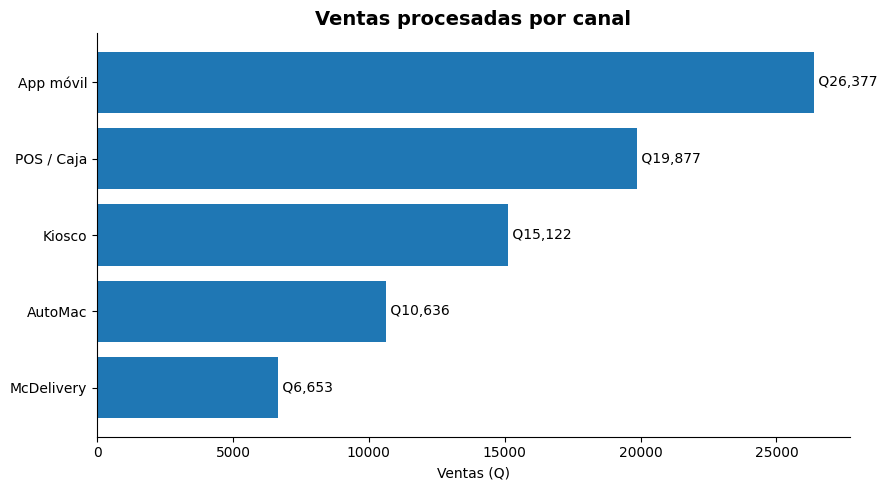

In [61]:
# ============================================
# VISUALIZACIÓN - VENTAS POR CANAL
# ============================================

datos_grafica = (
    kpi_canales
    .sort_values("ventas")
)

fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.barh(
    datos_grafica["canal"],
    datos_grafica["ventas"]
)

ax.set_title(
    "Ventas procesadas por canal",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Ventas (Q)")
ax.set_ylabel("")

# Etiquetas
for i, valor in enumerate(
    datos_grafica["ventas"]
):
    ax.text(
        valor,
        i,
        f" Q{valor:,.0f}",
        va="center"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

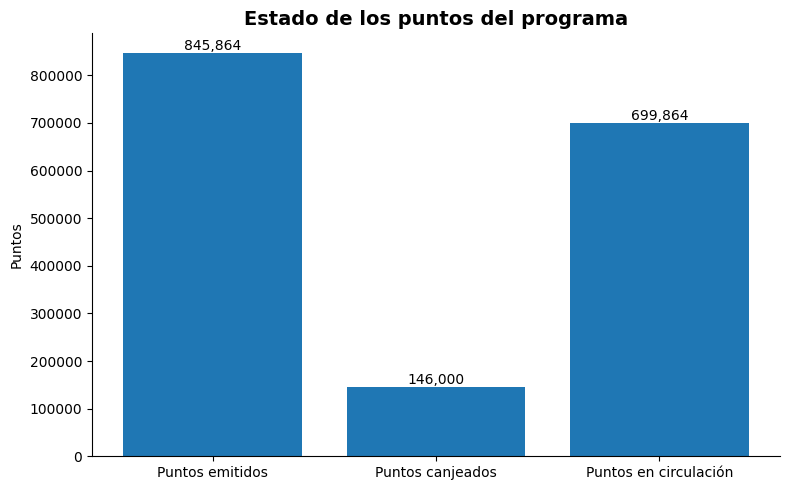

In [62]:
# ============================================
# VISUALIZACIÓN - EMISIÓN VS CANJE
# ============================================

metricas_puntos = pd.DataFrame({
    "metrica": [
        "Puntos emitidos",
        "Puntos canjeados",
        "Puntos en circulación"
    ],
    "puntos": [
        puntos_emitidos,
        puntos_canjeados,
        puntos_circulacion
    ]
})

fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.bar(
    metricas_puntos["metrica"],
    metricas_puntos["puntos"]
)

ax.set_title(
    "Estado de los puntos del programa",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylabel("Puntos")

for i, valor in enumerate(
    metricas_puntos["puntos"]
):
    ax.text(
        i,
        valor,
        f"{valor:,.0f}",
        ha="center",
        va="bottom"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [63]:
# ============================================
# RECOMPENSAS MÁS CANJEADAS
# ============================================

canjes_analisis = fact_points[
    fact_points["motivo"] == "CANJE"
].merge(
    dim_reward[
        [
            "reward_key",
            "nombre_recompensa",
            "categoria",
            "costo_puntos"
        ]
    ],
    on="reward_key",
    how="left"
)

ranking_recompensas = (
    canjes_analisis
    .groupby(
        [
            "nombre_recompensa",
            "categoria",
            "costo_puntos"
        ],
        as_index=False
    )
    .agg(
        numero_canjes=("ledger_id", "count")
    )
    .sort_values(
        "numero_canjes",
        ascending=False
    )
)

print("RECOMPENSAS MÁS CANJEADAS")
print("=" * 65)

display(ranking_recompensas)

RECOMPENSAS MÁS CANJEADAS


,nombre_recompensa,categoria,costo_puntos,numero_canjes
4,Papas pequeñas,Acompañamiento,1500,18
0,Bebida mediana,Bebida,2000,16
5,Sundae,Postre,2500,15
1,Hamburguesa,Producto principal,4000,8
3,McNuggets 6 piezas,Producto principal,5000,2
2,McCombo,Combo,7500,1


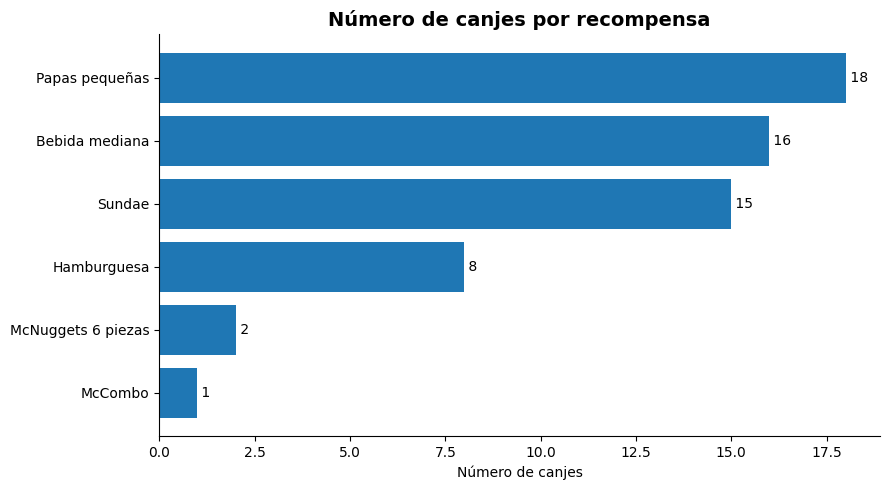

In [64]:
# ============================================
# VISUALIZACIÓN - RECOMPENSAS CANJEADAS
# ============================================

datos_rewards = (
    ranking_recompensas
    .sort_values("numero_canjes")
)

fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.barh(
    datos_rewards["nombre_recompensa"],
    datos_rewards["numero_canjes"]
)

ax.set_title(
    "Número de canjes por recompensa",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Número de canjes")
ax.set_ylabel("")

for i, valor in enumerate(
    datos_rewards["numero_canjes"]
):
    ax.text(
        valor,
        i,
        f" {valor}",
        va="center"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [65]:
# ============================================
# EVOLUCIÓN MENSUAL DE VENTAS
# ============================================

ventas_mensuales = fact_orders.copy()

ventas_mensuales["mes"] = (
    ventas_mensuales["fecha_orden"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

ventas_mensuales = (
    ventas_mensuales
    .groupby("mes", as_index=False)
    .agg(
        ventas=("monto_total", "sum"),
        ordenes=("order_id", "nunique"),
        clientes=("customer_id", "nunique")
    )
)

print("ACTIVIDAD MENSUAL")
print("=" * 65)

display(ventas_mensuales.tail(12))

ACTIVIDAD MENSUAL


,mes,ventas,ordenes,clientes
1,2025-10-01,7591.99,131,105
2,2025-11-01,6386.52,111,85
3,2025-12-01,7256.61,132,94
4,2026-01-01,6834.92,124,94
5,2026-02-01,5756.58,99,77
6,2026-03-01,7545.64,129,95
7,2026-04-01,6558.79,124,98
8,2026-05-01,6501.31,121,91
9,2026-06-01,4394.58,79,65
10,2026-07-01,6831.75,127,94


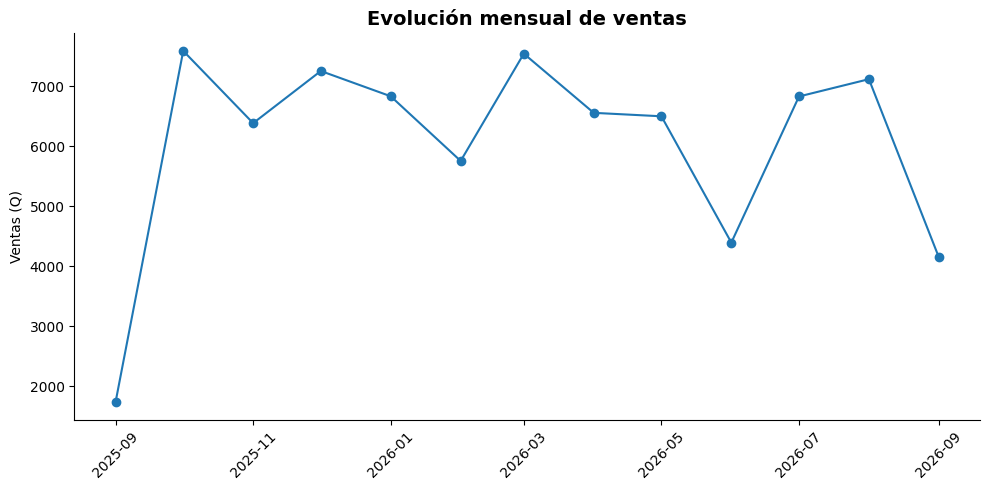

In [66]:
# ============================================
# VISUALIZACIÓN - VENTAS MENSUALES
# ============================================

fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.plot(
    ventas_mensuales["mes"],
    ventas_mensuales["ventas"],
    marker="o"
)

ax.set_title(
    "Evolución mensual de ventas",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("")
ax.set_ylabel("Ventas (Q)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [67]:
# ============================================
# TABLA RESUMEN DE KPIs
# ============================================

kpi_summary = pd.DataFrame({
    "KPI": [
        "Ventas procesadas",
        "Órdenes pagadas",
        "Clientes compradores",
        "Ticket promedio",
        "Puntos emitidos",
        "Puntos canjeados",
        "Puntos en circulación",
        "Tasa de canje"
    ],

    "Valor": [
        f"Q{ventas_totales:,.2f}",
        f"{ordenes_totales:,}",
        f"{clientes_compradores:,}",
        f"Q{ticket_promedio:,.2f}",
        f"{puntos_emitidos:,.0f}",
        f"{puntos_canjeados:,.0f}",
        f"{puntos_circulacion:,.0f}",
        f"{tasa_canje:.2f}%"
    ]
})

print("RESUMEN EJECUTIVO DEL PROGRAMA")
print("=" * 65)

display(kpi_summary)

RESUMEN EJECUTIVO DEL PROGRAMA


,KPI,Valor
0,Ventas procesadas,"Q78,664.13"
1,Órdenes pagadas,"1,413"
2,Clientes compradores,200
3,Ticket promedio,Q55.67
4,Puntos emitidos,"845,864"
5,Puntos canjeados,"146,000"
6,Puntos en circulación,"699,864"
7,Tasa de canje,17.26%


## 6. Analítica avanzada y Machine Learning

### 6.1 Feature Engineering


Una vez construida la capa analítica del Data Warehouse, los datos pueden utilizarse para generar variables que describan el comportamiento de cada cliente.

Para esta prueba de concepto se construye una tabla de características a nivel de cliente utilizando información histórica de compras y del programa de recompensas.

Las principales variables generadas son:

- **Recencia:** días transcurridos desde la última compra.
- **Frecuencia:** número de compras realizadas.
- **Gasto total:** monto acumulado de las compras.
- **Ticket promedio:** valor promedio de las órdenes.
- **Puntos ganados:** puntos acumulados mediante compras.
- **Número de canjes:** cantidad de recompensas utilizadas.
- **Puntos canjeados:** puntos utilizados en recompensas.
- **Diversidad de canales:** cantidad de canales distintos utilizados.

Estas características permiten resumir el comportamiento de los clientes y constituyen la entrada para un modelo de Machine Learning orientado a identificar posibles señales de abandono.

In [39]:
# ============================================
# 5.1 FEATURE ENGINEERING - COMPRAS
# ============================================

# Fecha de referencia del análisis
fecha_modelo = fecha_referencia

# Agregamos información de compras por cliente
features_compras = (
    fact_orders
    .groupby("customer_id")
    .agg(
        ultima_compra=("fecha_orden", "max"),
        frecuencia_compras=("order_id", "nunique"),
        gasto_total=("monto_total", "sum"),
        ticket_promedio=("monto_total", "mean"),
        canales_utilizados=("canal", "nunique")
    )
    .reset_index()
)

# Calculamos recencia
features_compras["recencia_dias"] = (
    fecha_modelo - features_compras["ultima_compra"]
).dt.days

print("FEATURES DE COMPORTAMIENTO DE COMPRA")
print("-" * 60)

display(features_compras.head(10))

FEATURES DE COMPORTAMIENTO DE COMPRA
------------------------------------------------------------


,customer_id,ultima_compra,frecuencia_compras,gasto_total,ticket_promedio,canales_utilizados,recencia_dias
0,CUST_0001,2026-05-18 00:20:00,7,417.32,59.617143,4,126
1,CUST_0002,2026-01-30 03:59:00,3,107.56,35.853333,2,234
2,CUST_0003,2026-07-19 03:41:00,3,115.70,38.566667,3,64
3,CUST_0004,2026-09-01 22:58:00,10,496.00,49.600000,5,20
4,CUST_0005,2026-05-10 07:12:00,3,139.93,46.643333,2,134
5,CUST_0006,2026-08-24 14:18:00,4,285.62,71.405000,2,28
6,CUST_0007,2026-09-11 07:30:00,7,262.11,37.444286,4,10
7,CUST_0008,2026-04-28 16:22:00,5,317.14,63.428000,3,146
8,CUST_0009,2026-08-08 18:33:00,7,338.31,48.330000,5,44
9,CUST_0010,2026-08-15 11:28:00,9,668.94,74.326667,4,37


In [40]:
# ============================================
# FEATURE ENGINEERING - PROGRAMA DE PUNTOS
# ============================================

# Puntos ganados
features_creditos = (
    fact_points[
        fact_points["tipo_movimiento"] == "CREDITO"
    ]
    .groupby("customer_id")
    .agg(
        puntos_ganados=("puntos", "sum")
    )
    .reset_index()
)

# Información de canjes
features_canjes = (
    fact_points[
        fact_points["motivo"] == "CANJE"
    ]
    .groupby("customer_id")
    .agg(
        numero_canjes=("ledger_id", "count"),
        puntos_canjes=("puntos", "sum")
    )
    .reset_index()
)

# Convertimos los débitos a cantidad positiva
features_canjes["puntos_canjeados"] = abs(
    features_canjes["puntos_canjes"]
)

features_canjes = features_canjes.drop(
    columns=["puntos_canjes"]
)

print("FEATURES DEL PROGRAMA DE PUNTOS")
print("-" * 60)

display(features_creditos.head())
display(features_canjes.head())

FEATURES DEL PROGRAMA DE PUNTOS
------------------------------------------------------------


,customer_id,puntos_ganados
0,CUST_0001,4481
1,CUST_0002,1116
2,CUST_0003,1327
3,CUST_0004,5603
4,CUST_0005,1633


,customer_id,numero_canjes,puntos_canjeados
0,CUST_0008,1,2500
1,CUST_0012,1,1500
2,CUST_0015,1,2500
3,CUST_0018,1,4000
4,CUST_0019,1,2000


In [41]:
# ============================================
# FEATURE TABLE
# ============================================

customer_features = (
    dim_customer[
        [
            "customer_id",
            "fecha_registro",
            "ciudad",
            "estado_cuenta",
            "acepta_promociones"
        ]
    ]
    .merge(
        features_compras,
        on="customer_id",
        how="left"
    )
    .merge(
        features_creditos,
        on="customer_id",
        how="left"
    )
    .merge(
        features_canjes,
        on="customer_id",
        how="left"
    )
)

# Clientes sin compras o canjes
columnas_cero = [
    "frecuencia_compras",
    "gasto_total",
    "ticket_promedio",
    "canales_utilizados",
    "puntos_ganados",
    "numero_canjes",
    "puntos_canjeados"
]

customer_features[columnas_cero] = (
    customer_features[columnas_cero]
    .fillna(0)
)

# Si un cliente nunca ha comprado, calculamos la
# recencia desde su fecha de registro.
customer_features["recencia_dias"] = (
    customer_features["recencia_dias"]
    .fillna(
        (
            fecha_modelo -
            customer_features["fecha_registro"]
        ).dt.days
    )
    .astype(int)
)

# Tipos enteros
customer_features[
    [
        "frecuencia_compras",
        "canales_utilizados",
        "puntos_ganados",
        "numero_canjes",
        "puntos_canjeados"
    ]
] = customer_features[
    [
        "frecuencia_compras",
        "canales_utilizados",
        "puntos_ganados",
        "numero_canjes",
        "puntos_canjeados"
    ]
].astype(int)

print("CUSTOMER FEATURE TABLE")
print("=" * 60)

print(
    f"Clientes representados: "
    f"{len(customer_features):,}"
)

print(
    f"Variables disponibles: "
    f"{len(customer_features.columns)}"
)

display(customer_features.head(10))

CUSTOMER FEATURE TABLE
Clientes representados: 200
Variables disponibles: 14


,customer_id,fecha_registro,ciudad,estado_cuenta,acepta_promociones,ultima_compra,frecuencia_compras,gasto_total,ticket_promedio,canales_utilizados,recencia_dias,puntos_ganados,numero_canjes,puntos_canjeados
0,CUST_0001,2024-11-07,Ciudad de Guatemala,activa,True,2026-05-18 00:20:00,7,417.32,59.617143,4,126,4481,0,0
1,CUST_0002,2026-05-01,Quetzaltenango,activa,False,2026-01-30 03:59:00,3,107.56,35.853333,2,234,1116,0,0
2,CUST_0003,2026-07-29,Villa Nueva,activa,True,2026-07-19 03:41:00,3,115.70,38.566667,3,64,1327,0,0
3,CUST_0004,2024-07-25,Mixco,activa,False,2026-09-01 22:58:00,10,496.00,49.600000,5,20,5603,0,0
4,CUST_0005,2025-11-15,Ciudad de Guatemala,activa,True,2026-05-10 07:12:00,3,139.93,46.643333,2,134,1633,0,0
5,CUST_0006,2025-12-16,Ciudad de Guatemala,activa,False,2026-08-24 14:18:00,4,285.62,71.405000,2,28,2855,0,0
6,CUST_0007,2026-01-07,Ciudad de Guatemala,activa,True,2026-09-11 07:30:00,7,262.11,37.444286,4,10,2870,0,0
7,CUST_0008,2026-04-03,Antigua Guatemala,activa,True,2026-04-28 16:22:00,5,317.14,63.428000,3,146,3311,1,2500
8,CUST_0009,2024-07-30,Mixco,activa,False,2026-08-08 18:33:00,7,338.31,48.330000,5,44,3434,0,0
9,CUST_0010,2026-05-11,Villa Nueva,activa,True,2026-08-15 11:28:00,9,668.94,74.326667,4,37,7158,0,0


In [42]:
# ============================================
# SALDO ACTUAL COMO FEATURE
# ============================================

customer_features = customer_features.merge(
    df_saldos_actualizados[
        [
            "customer_id",
            "saldo_puntos"
        ]
    ],
    on="customer_id",
    how="left"
)

customer_features["saldo_puntos"] = (
    customer_features["saldo_puntos"]
    .fillna(0)
    .astype(int)
)

print("FEATURE TABLE ACTUALIZADA")
print("-" * 60)

display(
    customer_features[
        [
            "customer_id",
            "recencia_dias",
            "frecuencia_compras",
            "gasto_total",
            "ticket_promedio",
            "puntos_ganados",
            "numero_canjes",
            "puntos_canjeados",
            "saldo_puntos"
        ]
    ].head(10)
)

FEATURE TABLE ACTUALIZADA
------------------------------------------------------------


,customer_id,recencia_dias,frecuencia_compras,gasto_total,ticket_promedio,puntos_ganados,numero_canjes,puntos_canjeados,saldo_puntos
0,CUST_0001,126,7,417.32,59.617143,4481,0,0,4481
1,CUST_0002,234,3,107.56,35.853333,1116,0,0,1116
2,CUST_0003,64,3,115.70,38.566667,1327,0,0,1327
3,CUST_0004,20,10,496.00,49.600000,5603,0,0,5603
4,CUST_0005,134,3,139.93,46.643333,1633,0,0,1633
5,CUST_0006,28,4,285.62,71.405000,2855,0,0,2855
6,CUST_0007,10,7,262.11,37.444286,2870,0,0,2870
7,CUST_0008,146,5,317.14,63.428000,3311,1,2500,811
8,CUST_0009,44,7,338.31,48.330000,3434,0,0,3434
9,CUST_0010,37,9,668.94,74.326667,7158,0,0,7158


In [43]:
# ============================================
# VALIDACIÓN DE FEATURE ENGINEERING
# ============================================

assert customer_features["customer_id"].is_unique

assert len(customer_features) == len(
    dim_customer
)

assert (
    customer_features["recencia_dias"] >= 0
).all()

assert (
    customer_features["frecuencia_compras"] >= 0
).all()

assert (
    customer_features["gasto_total"] >= 0
).all()

assert (
    customer_features["saldo_puntos"] >= 0
).all()

print("✓ Feature Table validada correctamente.")
print("✓ Existe una fila por cliente.")
print("✓ No existen recencias negativas.")
print("✓ No existen frecuencias o gastos negativos.")
print("✓ Los saldos son válidos.")

✓ Feature Table validada correctamente.
✓ Existe una fila por cliente.
✓ No existen recencias negativas.
✓ No existen frecuencias o gastos negativos.
✓ Los saldos son válidos.


### 6.2 Modelo de abandono de clientes


Como propuesta de integración de Machine Learning, se implementa una prueba de concepto de un modelo orientado a identificar clientes con señales de posible abandono del programa.

En un entorno productivo, la variable objetivo debería construirse utilizando información histórica real, por ejemplo, identificando clientes que dejaron de comprar durante un período determinado.

Debido a que esta prueba de concepto utiliza datos sintéticos y no cuenta con etiquetas históricas reales de abandono, se construirá una variable objetivo simulada. Esta variable se utiliza únicamente para demostrar cómo podría integrarse un modelo de Machine Learning dentro de la arquitectura propuesta.

Para evitar utilizar directamente la misma variable con la que se construye la etiqueta, el modelo utilizará características de comportamiento como frecuencia de compra, gasto, ticket promedio, uso de canales, puntos y canjes.

El objetivo de esta sección no es afirmar que el modelo posee capacidad predictiva real sobre clientes de McDonald's, sino demostrar técnicamente el flujo de entrenamiento, evaluación y generación de predicciones.

In [44]:
# ============================================
# 5.2 DEFINICIÓN DE VARIABLE OBJETIVO
# ============================================

model_data = customer_features.copy()

# Definición académica de abandono para la POC:
# 1 = cliente con más de 60 días desde su última compra
# 0 = cliente con actividad más reciente
UMBRAL_ABANDONO_DIAS = 60

model_data["abandono"] = np.where(
    model_data["recencia_dias"] > UMBRAL_ABANDONO_DIAS,
    1,
    0
)

print("VARIABLE OBJETIVO")
print("=" * 60)

print(
    f"Umbral utilizado: "
    f"{UMBRAL_ABANDONO_DIAS} días"
)

print("\nDistribución de la variable objetivo:")

print(
    model_data["abandono"]
    .value_counts()
    .rename(index={
        0: "Activo",
        1: "Posible abandono"
    })
)

print("\nDistribución porcentual:")

print(
    model_data["abandono"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename(index={
        0: "Activo",
        1: "Posible abandono"
    })
)

display(
    model_data[
        [
            "customer_id",
            "recencia_dias",
            "frecuencia_compras",
            "gasto_total",
            "numero_canjes",
            "abandono"
        ]
    ].head(10)
)

VARIABLE OBJETIVO
Umbral utilizado: 60 días

Distribución de la variable objetivo:
abandono
Activo              137
Posible abandono     63
Name: count, dtype: int64

Distribución porcentual:
abandono
Activo              68.5
Posible abandono    31.5
Name: proportion, dtype: float64


,customer_id,recencia_dias,frecuencia_compras,gasto_total,numero_canjes,abandono
0,CUST_0001,126,7,417.32,0,1
1,CUST_0002,234,3,107.56,0,1
2,CUST_0003,64,3,115.70,0,1
3,CUST_0004,20,10,496.00,0,0
4,CUST_0005,134,3,139.93,0,1
5,CUST_0006,28,4,285.62,0,0
6,CUST_0007,10,7,262.11,0,0
7,CUST_0008,146,5,317.14,1,1
8,CUST_0009,44,7,338.31,0,0
9,CUST_0010,37,9,668.94,0,0


In [45]:
# ============================================
# PREPARACIÓN DE VARIABLES PARA ML
# ============================================

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Variables predictoras
feature_columns = [
    "frecuencia_compras",
    "gasto_total",
    "ticket_promedio",
    "canales_utilizados",
    "puntos_ganados",
    "numero_canjes",
    "puntos_canjeados",
    "saldo_puntos"
]

X = model_data[feature_columns].copy()
y = model_data["abandono"].copy()

print("DATASET PARA MACHINE LEARNING")
print("-" * 60)

print(f"Observaciones: {len(X):,}")
print(f"Variables predictoras: {len(feature_columns)}")
print(f"Valores nulos: {X.isna().sum().sum()}")

display(X.head())

DATASET PARA MACHINE LEARNING
------------------------------------------------------------
Observaciones: 200
Variables predictoras: 8
Valores nulos: 0


,frecuencia_compras,gasto_total,ticket_promedio,canales_utilizados,puntos_ganados,numero_canjes,puntos_canjeados,saldo_puntos
0,7,417.32,59.617143,4,4481,0,0,4481
1,3,107.56,35.853333,2,1116,0,0,1116
2,3,115.70,38.566667,3,1327,0,0,1327
3,10,496.00,49.600000,5,5603,0,0,5603
4,3,139.93,46.643333,2,1633,0,0,1633


In [46]:
# ============================================
# TRAIN / TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("DIVISIÓN DE DATOS")
print("-" * 60)

print(
    f"Entrenamiento: "
    f"{len(X_train)} clientes"
)

print(
    f"Prueba: "
    f"{len(X_test)} clientes"
)

print("\nDistribución entrenamiento:")
print(y_train.value_counts())

print("\nDistribución prueba:")
print(y_test.value_counts())

DIVISIÓN DE DATOS
------------------------------------------------------------
Entrenamiento: 150 clientes
Prueba: 50 clientes

Distribución entrenamiento:
abandono
0    103
1     47
Name: count, dtype: int64

Distribución prueba:
abandono
0    34
1    16
Name: count, dtype: int64


In [47]:
# ============================================
# ENTRENAMIENTO DEL MODELO
# ============================================

churn_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        LogisticRegression(
            random_state=42,
            max_iter=1000,
            class_weight="balanced"
        )
    )
])

churn_model.fit(
    X_train,
    y_train
)

print("✓ Modelo entrenado correctamente.")
print("Modelo: Regresión Logística")

✓ Modelo entrenado correctamente.
Modelo: Regresión Logística


In [48]:
# ============================================
# EVALUACIÓN DEL MODELO
# ============================================

y_pred = churn_model.predict(X_test)

y_prob = churn_model.predict_proba(
    X_test
)[:, 1]

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

auc = roc_auc_score(
    y_test,
    y_prob
)

print("EVALUACIÓN DEL MODELO")
print("=" * 60)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1 Score:  {f1:.3f}")
print(f"ROC-AUC:   {auc:.3f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Activo",
            "Posible abandono"
        ],
        zero_division=0
    )
)

EVALUACIÓN DEL MODELO
Accuracy:  0.640
Precision: 0.444
Recall:    0.500
F1 Score:  0.471
ROC-AUC:   0.640

Classification Report:
                  precision    recall  f1-score   support

          Activo       0.75      0.71      0.73        34
Posible abandono       0.44      0.50      0.47        16

        accuracy                           0.64        50
       macro avg       0.60      0.60      0.60        50
    weighted avg       0.65      0.64      0.65        50



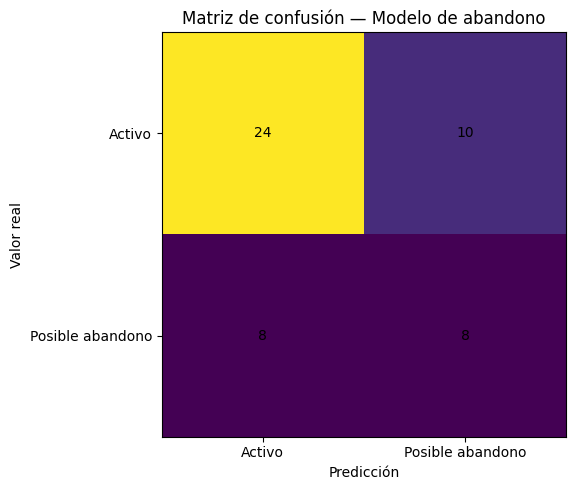

In [49]:
# ============================================
# MATRIZ DE CONFUSIÓN
# ============================================

cm = confusion_matrix(
    y_test,
    y_pred
)

fig, ax = plt.subplots(
    figsize=(6, 5)
)

imagen = ax.imshow(cm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels([
    "Activo",
    "Posible abandono"
])

ax.set_yticklabels([
    "Activo",
    "Posible abandono"
])

ax.set_xlabel("Predicción")
ax.set_ylabel("Valor real")

ax.set_title(
    "Matriz de confusión — Modelo de abandono"
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [50]:
# ============================================
# SCORING DE CLIENTES
# ============================================

model_data["probabilidad_abandono"] = (
    churn_model.predict_proba(
        model_data[feature_columns]
    )[:, 1]
)

model_data["prediccion_abandono"] = (
    churn_model.predict(
        model_data[feature_columns]
    )
)

print("SCORING DE CLIENTES")
print("=" * 60)

display(
    model_data[
        [
            "customer_id",
            "recencia_dias",
            "frecuencia_compras",
            "gasto_total",
            "numero_canjes",
            "probabilidad_abandono",
            "prediccion_abandono"
        ]
    ]
    .sort_values(
        "probabilidad_abandono",
        ascending=False
    )
    .head(15)
)

SCORING DE CLIENTES


,customer_id,recencia_dias,frecuencia_compras,gasto_total,numero_canjes,probabilidad_abandono,prediccion_abandono
142,CUST_0143,250,1,78.57,0,0.911160,1
36,CUST_0037,259,1,71.32,0,0.901812,1
162,CUST_0163,61,3,304.09,0,0.871124,1
132,CUST_0133,55,2,146.33,0,0.849798,1
123,CUST_0124,135,2,146.13,0,0.849663,1
138,CUST_0139,7,1,31.32,0,0.833223,1
32,CUST_0033,75,2,89.28,0,0.823890,1
159,CUST_0160,79,3,293.55,0,0.817182,1
47,CUST_0048,23,3,282.49,0,0.810795,1
50,CUST_0051,42,3,226.24,0,0.807405,1


In [51]:
# ============================================
# VALIDACIÓN DEL PIPELINE DE ML
# ============================================

assert len(
    model_data["probabilidad_abandono"]
) == len(customer_features)

assert (
    model_data["probabilidad_abandono"]
    .between(0, 1)
).all()

assert set(
    model_data["prediccion_abandono"].unique()
).issubset({0, 1})

assert (
    model_data[feature_columns]
    .isna()
    .sum()
    .sum()
    == 0
)

print("✓ Pipeline de Machine Learning validado.")
print("✓ Todos los clientes recibieron un score.")
print("✓ Las probabilidades se encuentran entre 0 y 1.")
print("✓ No existen valores nulos en las variables del modelo.")

✓ Pipeline de Machine Learning validado.
✓ Todos los clientes recibieron un score.
✓ Las probabilidades se encuentran entre 0 y 1.
✓ No existen valores nulos en las variables del modelo.


### 6.3 Campaign Engine y activación


El resultado de un modelo predictivo genera valor cuando puede integrarse nuevamente con los sistemas operacionales para apoyar una acción de negocio.

En esta prueba de concepto, el Campaign Engine utiliza el score generado por el modelo de abandono para identificar clientes que presentan señales de posible abandono y que, además, han autorizado recibir promociones.

Los clientes seleccionados son segmentados según su comportamiento y reciben una oferta simulada orientada a incentivar una nueva interacción con el programa de recompensas.

Finalmente, se genera una tabla de activación que representa la información que podría enviarse nuevamente hacia la App móvil.

Este proceso cierra el ciclo de la arquitectura:

**Datos → Data Warehouse → Feature Engineering → Machine Learning → Campaign Engine → App móvil.**

Las campañas propuestas son simuladas y tienen como objetivo demostrar la integración técnica del modelo dentro del pipeline.

In [53]:
# ============================================
# 5.3 CAMPAIGN ENGINE
# ============================================

campaign_candidates = model_data[
    (model_data["prediccion_abandono"] == 1)
    &
    (model_data["acepta_promociones"] == True)
    &
    (model_data["estado_cuenta"] == "activa")
].copy()

print("CAMPAIGN ENGINE")
print("=" * 60)

print(
    f"Clientes evaluados: "
    f"{len(model_data):,}"
)

print(
    f"Clientes clasificados con posible abandono: "
    f"{(model_data['prediccion_abandono'] == 1).sum():,}"
)

print(
    f"Clientes elegibles para campaña: "
    f"{len(campaign_candidates):,}"
)

display(
    campaign_candidates[
        [
            "customer_id",
            "recencia_dias",
            "frecuencia_compras",
            "gasto_total",
            "saldo_puntos",
            "probabilidad_abandono",
            "acepta_promociones"
        ]
    ]
    .sort_values(
        "probabilidad_abandono",
        ascending=False
    )
    .head(10)
)

CAMPAIGN ENGINE
Clientes evaluados: 200
Clientes clasificados con posible abandono: 82
Clientes elegibles para campaña: 52


,customer_id,recencia_dias,frecuencia_compras,gasto_total,saldo_puntos,probabilidad_abandono,acepta_promociones
142,CUST_0143,250,1,78.57,785,0.911160,True
36,CUST_0037,259,1,71.32,713,0.901812,True
162,CUST_0163,61,3,304.09,3040,0.871124,True
138,CUST_0139,7,1,31.32,313,0.833223,True
32,CUST_0033,75,2,89.28,1070,0.823890,True
159,CUST_0160,79,3,293.55,2935,0.817182,True
137,CUST_0138,124,2,82.25,822,0.787518,True
114,CUST_0115,42,3,207.16,2243,0.763917,True
52,CUST_0053,27,3,155.37,1661,0.762838,True
173,CUST_0174,32,4,231.22,810,0.753959,True


In [54]:
# ============================================
# SEGMENTACIÓN PARA CAMPAÑAS
# ============================================

def asignar_segmento(row):

    # Cliente de alto valor histórico
    if (
        row["gasto_total"] >=
        customer_features["gasto_total"].median()
        and
        row["frecuencia_compras"] >=
        customer_features["frecuencia_compras"].median()
    ):
        return "ALTO_VALOR"

    # Cliente que posee suficientes puntos acumulados
    elif row["saldo_puntos"] >= 1500:
        return "SALDO_DISPONIBLE"

    # Resto de clientes
    else:
        return "REACTIVACION"


campaign_candidates["segmento_campana"] = (
    campaign_candidates.apply(
        asignar_segmento,
        axis=1
    )
)

print("SEGMENTOS DE CAMPAÑA")
print("-" * 60)

print(
    campaign_candidates[
        "segmento_campana"
    ].value_counts()
)

SEGMENTOS DE CAMPAÑA
------------------------------------------------------------
segmento_campana
SALDO_DISPONIBLE    33
REACTIVACION        16
ALTO_VALOR           3
Name: count, dtype: int64


In [55]:
# ============================================
# ASIGNACIÓN DE OFERTAS
# ============================================

def asignar_oferta(segmento):

    if segmento == "ALTO_VALOR":
        return (
            "Beneficio especial por fidelidad"
        )

    elif segmento == "SALDO_DISPONIBLE":
        return (
            "Recordatorio para utilizar puntos disponibles"
        )

    else:
        return (
            "Oferta de reactivación en próxima compra"
        )


campaign_candidates["oferta"] = (
    campaign_candidates[
        "segmento_campana"
    ].apply(asignar_oferta)
)

display(
    campaign_candidates[
        [
            "customer_id",
            "segmento_campana",
            "probabilidad_abandono",
            "saldo_puntos",
            "oferta"
        ]
    ]
    .sort_values(
        "probabilidad_abandono",
        ascending=False
    )
    .head(15)
)

,customer_id,segmento_campana,probabilidad_abandono,saldo_puntos,oferta
142,CUST_0143,REACTIVACION,0.911160,785,Oferta de reactivación en próxima compra
36,CUST_0037,REACTIVACION,0.901812,713,Oferta de reactivación en próxima compra
162,CUST_0163,SALDO_DISPONIBLE,0.871124,3040,Recordatorio para utilizar puntos disponibles
138,CUST_0139,REACTIVACION,0.833223,313,Oferta de reactivación en próxima compra
32,CUST_0033,REACTIVACION,0.823890,1070,Oferta de reactivación en próxima compra
159,CUST_0160,SALDO_DISPONIBLE,0.817182,2935,Recordatorio para utilizar puntos disponibles
137,CUST_0138,REACTIVACION,0.787518,822,Oferta de reactivación en próxima compra
114,CUST_0115,SALDO_DISPONIBLE,0.763917,2243,Recordatorio para utilizar puntos disponibles
52,CUST_0053,SALDO_DISPONIBLE,0.762838,1661,Recordatorio para utilizar puntos disponibles
173,CUST_0174,REACTIVACION,0.753959,810,Oferta de reactivación en próxima compra


In [56]:
# ============================================
# ACTIVACIÓN HACIA LA APP
# ============================================

df_campaign_activation = campaign_candidates[
    [
        "customer_id",
        "probabilidad_abandono",
        "segmento_campana",
        "oferta"
    ]
].copy()

df_campaign_activation["canal_activacion"] = (
    "App móvil"
)

df_campaign_activation["fecha_generacion"] = (
    fecha_referencia
)

df_campaign_activation["estado_envio"] = (
    "PENDIENTE"
)

# ID único de campaña
df_campaign_activation.insert(
    0,
    "campaign_id",
    [
        f"CAMP_{i:05d}"
        for i in range(
            1,
            len(df_campaign_activation) + 1
        )
    ]
)

print("TABLA DE ACTIVACIÓN")
print("=" * 60)

print(
    f"Campañas generadas: "
    f"{len(df_campaign_activation):,}"
)

display(
    df_campaign_activation
    .sort_values(
        "probabilidad_abandono",
        ascending=False
    )
    .head(15)
)

TABLA DE ACTIVACIÓN
Campañas generadas: 52


,campaign_id,customer_id,probabilidad_abandono,segmento_campana,oferta,canal_activacion,fecha_generacion,estado_envio
142,CAMP_00039,CUST_0143,0.911160,REACTIVACION,Oferta de reactivación en próxima compra,App móvil,2026-09-22,PENDIENTE
36,CAMP_00011,CUST_0037,0.901812,REACTIVACION,Oferta de reactivación en próxima compra,App móvil,2026-09-22,PENDIENTE
162,CAMP_00046,CUST_0163,0.871124,SALDO_DISPONIBLE,Recordatorio para utilizar puntos disponibles,App móvil,2026-09-22,PENDIENTE
138,CAMP_00037,CUST_0139,0.833223,REACTIVACION,Oferta de reactivación en próxima compra,App móvil,2026-09-22,PENDIENTE
32,CAMP_00009,CUST_0033,0.823890,REACTIVACION,Oferta de reactivación en próxima compra,App móvil,2026-09-22,PENDIENTE
159,CAMP_00044,CUST_0160,0.817182,SALDO_DISPONIBLE,Recordatorio para utilizar puntos disponibles,App móvil,2026-09-22,PENDIENTE
137,CAMP_00036,CUST_0138,0.787518,REACTIVACION,Oferta de reactivación en próxima compra,App móvil,2026-09-22,PENDIENTE
114,CAMP_00034,CUST_0115,0.763917,SALDO_DISPONIBLE,Recordatorio para utilizar puntos disponibles,App móvil,2026-09-22,PENDIENTE
52,CAMP_00015,CUST_0053,0.762838,SALDO_DISPONIBLE,Recordatorio para utilizar puntos disponibles,App móvil,2026-09-22,PENDIENTE
173,CAMP_00048,CUST_0174,0.753959,REACTIVACION,Oferta de reactivación en próxima compra,App móvil,2026-09-22,PENDIENTE


In [57]:
# ============================================
# VALIDACIÓN DEL CAMPAIGN ENGINE
# ============================================

# IDs de clientes que aceptan promociones
clientes_consentimiento = set(
    dim_customer.loc[
        dim_customer["acepta_promociones"] == True,
        "customer_id"
    ]
)

# Todos los clientes activados deben
# haber autorizado promociones
assert set(
    df_campaign_activation["customer_id"]
).issubset(clientes_consentimiento)

# IDs de cuentas activas
clientes_activos = set(
    dim_customer.loc[
        dim_customer["estado_cuenta"] == "activa",
        "customer_id"
    ]
)

assert set(
    df_campaign_activation["customer_id"]
).issubset(clientes_activos)

# IDs de clientes clasificados por el modelo
clientes_predichos_abandono = set(
    model_data.loc[
        model_data["prediccion_abandono"] == 1,
        "customer_id"
    ]
)

assert set(
    df_campaign_activation["customer_id"]
).issubset(clientes_predichos_abandono)

# Campaign IDs únicos
assert (
    df_campaign_activation["campaign_id"]
    .is_unique
)

print("✓ Campaign Engine validado correctamente.")
print("✓ Todos los clientes autorizaron promociones.")
print("✓ Todas las cuentas seleccionadas están activas.")
print("✓ Todos fueron seleccionados a partir del modelo.")
print("✓ Los campaign_id son únicos.")

✓ Campaign Engine validado correctamente.
✓ Todos los clientes autorizaron promociones.
✓ Todas las cuentas seleccionadas están activas.
✓ Todos fueron seleccionados a partir del modelo.
✓ Los campaign_id son únicos.


In [58]:
# ============================================
# RESUMEN DE LA ARQUITECTURA IMPLEMENTADA
# ============================================

print("=" * 70)
print("POC - SISTEMA DE RECOMPENSAS DE McDONALD'S")
print("=" * 70)

print("\n1. CAPA OPERACIONAL")
print(f"   Clientes:             {len(df_customers):,}")
print(f"   Órdenes:              {len(df_orders):,}")
print(f"   Reglas:               {len(df_rules):,}")
print(f"   Recompensas:          {len(df_rewards):,}")

print("\n2. SISTEMA DE LEALTAD")
print(f"   Órdenes procesadas:   {len(df_paid_orders):,}")
print(f"   Movimientos ledger:   {len(df_points_ledger):,}")
print(f"   Canjes realizados:    {len(df_redemptions):,}")

print("\n3. EVENT BUS")
print(f"   Eventos generados:    {len(df_event_bus):,}")

print("\n4. RAW DATA LAKE")
print(f"   Registros RAW:        {len(df_raw_corrupted):,}")

print("\n5. DATA QUALITY")
print(f"   Registros válidos:    {len(df_valid):,}")
print(f"   Registros rechazados: {len(df_rejected):,}")
print(f"   Calidad general:      {porcentaje_calidad:.2f}%")

print("\n6. DATA WAREHOUSE")
print(f"   dim_customer:         {len(dim_customer):,}")
print(f"   dim_reward:           {len(dim_reward):,}")
print(f"   fact_orders:          {len(fact_orders):,}")
print(f"   fact_points:          {len(fact_points):,}")

print("\n7. MACHINE LEARNING")
print(f"   Clientes modelados:   {len(model_data):,}")
print(f"   ROC-AUC POC:          {auc:.3f}")

print("\n8. ACTIVACIÓN")
print(f"   Campañas generadas:   {len(df_campaign_activation):,}")

print("\n" + "=" * 70)
print("PIPELINE EJECUTADO CORRECTAMENTE")
print("=" * 70)

POC - SISTEMA DE RECOMPENSAS DE McDONALD'S

1. CAPA OPERACIONAL
   Clientes:             200
   Órdenes:              1,500
   Reglas:               2
   Recompensas:          6

2. SISTEMA DE LEALTAD
   Órdenes procesadas:   1,430
   Movimientos ledger:   1,490
   Canjes realizados:    60

3. EVENT BUS
   Eventos generados:    2,920

4. RAW DATA LAKE
   Registros RAW:        2,930

5. DATA QUALITY
   Registros válidos:    2,900
   Registros rechazados: 30
   Calidad general:      98.98%

6. DATA WAREHOUSE
   dim_customer:         200
   dim_reward:           6
   fact_orders:          1,413
   fact_points:          1,490

7. MACHINE LEARNING
   Clientes modelados:   200
   ROC-AUC POC:          0.640

8. ACTIVACIÓN
   Campañas generadas:   52

PIPELINE EJECUTADO CORRECTAMENTE
